<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2026/blob/main/DISE%C3%91O2026PARTE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos**

<a name="inicio2"></a>


# **2. Diseño de Experimentos 2026 con R y Python - P2**

## **https://rpubs.com/jseferino/DOEP2**


## **4.** [1.3. EJEMPLO 1: DISTRIBUCIÓN CHI-CUADRADA](#T4)

## **5.** [EJEMPLO 2: DISTRIBUCIÓN MUESTRAL DE LA VARIANZA](#T5)

## **6.** [EJEMPLO 3: DISTRIBUCIÓN t DE STUDENT](#T6)

## **7.** [EJEMPLO 1: DISTRIBUCIÓN F](#T7)


## **8.** [EJEMPLO 2: TLC - COMPARACIÓN DE MEDIAS](#T8)

## **9.** [EJEMPLO 4: APROXIMACIÓN NORMAL DE LA BINOMIAL](#T9)


## **10.** [B.  EJEMPLO 1: ESTIMADORES DE LA VARIANZA](#T10)

## **11.** [Visualización de la consistencia del estimador de la media](#T11)

## **12.** [Comparación de eficiencia entre media y mediana](#T12)

## **13.** [EJEMPLO 2: ESTIMACIÓN DE PROPORCIÓN](#T13)

## **14.** [EJEMPLO 3: COMPARACIÓN DE DOS MEDIAS](#T14)

## **15.** [EJEMPLO 1: INTERVALO DE CONFIANZA PARA LA MEDIA](#T15)

## **16.** [EJEMPLO 2: INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES](#T16)

## **17.** [Cálculo del tamaño de muestra necesario](#T17)


## **18.** [EJEMPLO 3: INTERVALO DE CONFIANZA CON t DE STUDENT](#T18)

## **19.** [EJEMPLO 4: INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS](#T19)


## **20.** [EJEMPLOS 5 Y 6: INTERVALOS DE CONFIANZA PARA LA VARIANZA](#T20)

## **21.** [EJEMPLO 1: EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME](#T21)

## **22.** [DEMOSTRACIÓN DE CONSISTENCIA](#T22)

## **23.** [COMPARACIÓN DE ESTIMADORES: MLE vs INSESGADO](#T23)

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **1.3. EJEMPLO 1: DISTRIBUCIÓN CHI-CUADRADA**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

Valor b tal que P(χ²(6) ≤ b) = 0.95: 12.5916 


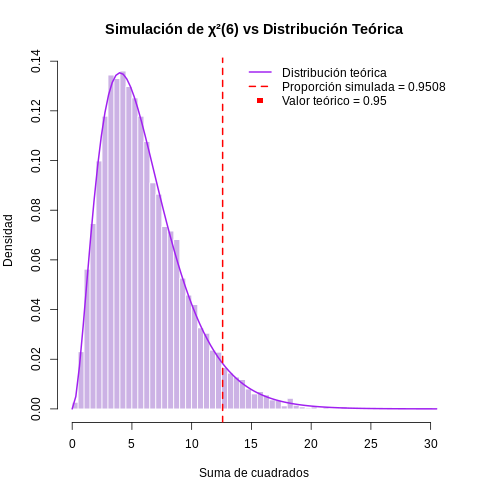

In [ ]:

# ============================================
# @title **B. EJEMPLO 1: DISTRIBUCIÓN CHI-CUADRADA**
# ============================================
%%R

# Parámetros
gl <- 6
confianza <- 0.95

# Valor crítico (cuantil)
b <- qchisq(confianza, df = gl)
cat("Valor b tal que P(χ²(6) ≤ b) = 0.95:", round(b, 4), "\n")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN χ²
# ============================================

# Crear secuencia de valores x
x_vals <- seq(0, 20, length.out = 500)
densidad <- dchisq(x_vals, df = gl)

# Región de probabilidad (0 a b)
x_fill <- seq(0, b, length.out = 100)
y_fill <- dchisq(x_fill, df = gl)

# Gráfico
par(mfrow = c(1, 1), mar = c(4, 4, 4, 2))
plot(x_vals, densidad, type = "l", lwd = 2, col = "purple",
     xlab = expression(chi^2), ylab = "Densidad",
     main = paste("Distribución χ² con", gl, "grados de libertad\n",
                  "P(χ² ≤", round(b, 4), ") = 0.95"))

polygon(c(x_fill, rev(x_fill)), c(y_fill, rep(0, length(x_fill))),
        col = rgb(0.6, 0.4, 0.8, 0.4), border = NA)
abline(v = b, lty = 2, col = "red", lwd = 2)
text(b + 0.5, max(densidad) * 0.6,
     labels = paste("b =", round(b, 4)), col = "red")

legend("topright", legend = paste("Área = 0.95"),
       fill = rgb(0.6, 0.4, 0.8, 0.4), bty = "n")

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN χ²
# ============================================

set.seed(123)
n_sim <- 10000
n <- 6

# Simular muestras de normales estándar y calcular suma de cuadrados
simulaciones <- replicate(n_sim, sum(rnorm(n)^2))

# Histograma de las simulaciones
hist(simulaciones, breaks = 50, prob = TRUE,
     col = rgb(0.6, 0.4, 0.8, 0.5), border = "white",
     main = "Simulación de χ²(6) vs Distribución Teórica",
     xlab = "Suma de cuadrados", ylab = "Densidad")

# Superponer curva teórica
curve(dchisq(x, df = gl), add = TRUE, col = "purple", lwd = 2)

# Línea del valor crítico
abline(v = b, col = "red", lty = 2, lwd = 2)

# Proporción de simulaciones ≤ b
proporcion <- mean(simulaciones <= b)
legend("topright",
       legend = c("Distribución teórica",
                  paste("Proporción simulada =", round(proporcion, 4)),
                  paste("Valor teórico = 0.95")),
       col = c("purple", "red", "red"), lty = c(1, 2, NA),
       pch = c(NA, NA, 15), lwd = c(2, 2, NA), bty = "n")




Valor b tal que P(χ²(6) ≤ b) = 0.95: 12.5916


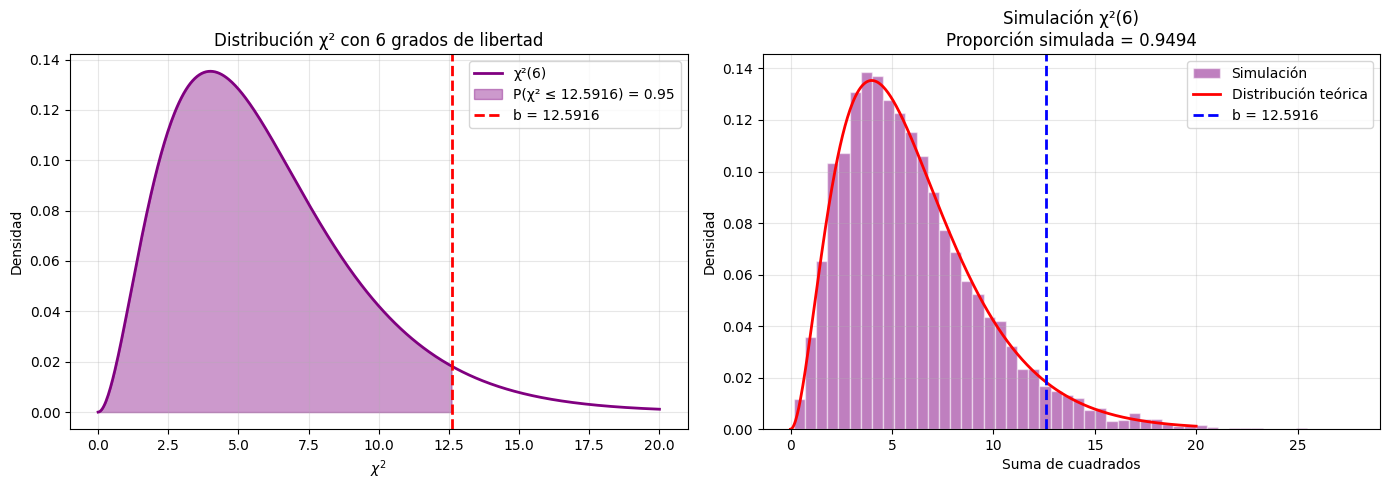

In [ ]:

# ============================================
# @title **C. EJEMPLO 1: DISTRIBUCIÓN CHI-CUADRADA**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parámetros
gl = 6
confianza = 0.95

# Valor crítico (cuantil)
b = chi2.ppf(confianza, df=gl)
print(f"Valor b tal que P(χ²(6) ≤ b) = 0.95: {b:.4f}")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN χ²
# ============================================

# Crear secuencia de valores x
x_vals = np.linspace(0, 20, 500)
densidad = chi2.pdf(x_vals, df=gl)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución teórica
ax1.plot(x_vals, densidad, 'purple', lw=2, label=f'χ²({gl})')

# Región de probabilidad (0 a b)
x_fill = np.linspace(0, b, 100)
y_fill = chi2.pdf(x_fill, df=gl)
ax1.fill_between(x_fill, y_fill, alpha=0.4, color='purple',
                  label=f'P(χ² ≤ {b:.4f}) = 0.95')
ax1.axvline(b, color='red', linestyle='--', lw=2, label=f'b = {b:.4f}')
ax1.set_xlabel(r'$\chi^2$')
ax1.set_ylabel('Densidad')
ax1.set_title(f'Distribución χ² con {gl} grados de libertad')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN χ²
# ============================================

np.random.seed(123)
n_sim = 10000
n = 6

# Simular muestras de normales estándar y calcular suma de cuadrados
simulaciones = np.array([np.sum(np.random.normal(0, 1, n)**2)
                          for _ in range(n_sim)])

# Histograma de las simulaciones
ax2.hist(simulaciones, bins=50, density=True, alpha=0.5,
         color='purple', edgecolor='white', label='Simulación')

# Superponer curva teórica
x_teorica = np.linspace(0, 20, 500)
y_teorica = chi2.pdf(x_teorica, df=gl)
ax2.plot(x_teorica, y_teorica, 'r-', lw=2, label='Distribución teórica')

# Línea del valor crítico
ax2.axvline(b, color='blue', linestyle='--', lw=2, label=f'b = {b:.4f}')

# Proporción de simulaciones ≤ b
proporcion = np.mean(simulaciones <= b)
ax2.set_xlabel('Suma de cuadrados')
ax2.set_ylabel('Densidad')
ax2.set_title(f'Simulación χ²({gl})\nProporción simulada = {proporcion:.4f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio2)

<a name="T5"></a>
## **5. EJEMPLO 2: DISTRIBUCIÓN MUESTRAL DE LA VARIANZA**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

Valores críticos de χ²(9):
  χ²_inferior = 3.3251 
  χ²_superior = 16.919 

Límites para S²:
  b1 = 0.3325 
  b2 = 1.6919 


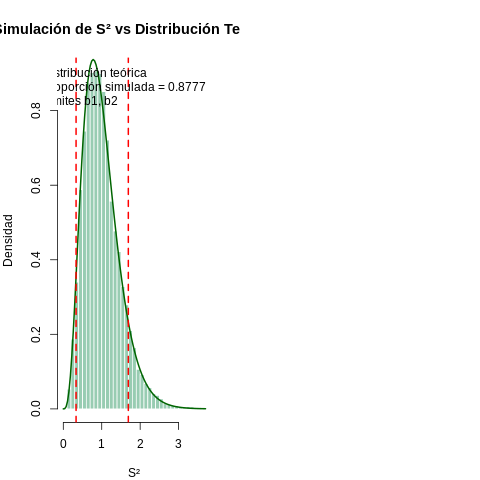

In [ ]:

# ============================================
# @title **B. EJEMPLO 2: DISTRIBUCIÓN MUESTRAL DE LA VARIANZA**
# ============================================
%%R
# Parámetros
n <- 10
gl <- n - 1  # 9 grados de libertad
confianza <- 0.90

# Valor crítico inferior y superior de chi-cuadrado
chi2_inferior <- qchisq((1 - confianza)/2, df = gl)  # 0.05 -> 3.325
chi2_superior <- qchisq((1 + confianza)/2, df = gl)  # 0.95 -> 16.919

# Convertir a límites para S^2 (σ^2 = 1)
b1 <- chi2_inferior / n
b2 <- chi2_superior / n

cat("Valores críticos de χ²(9):\n")
cat("  χ²_inferior =", round(chi2_inferior, 4), "\n")
cat("  χ²_superior =", round(chi2_superior, 4), "\n\n")
cat("Límites para S²:\n")
cat("  b1 =", round(b1, 4), "\n")
cat("  b2 =", round(b2, 4), "\n")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN χ²(9)
# ============================================

x_vals <- seq(0, 25, length.out = 500)
densidad <- dchisq(x_vals, df = gl)

# Regiones de probabilidad
x_fill_inf <- seq(0, chi2_inferior, length.out = 100)
y_fill_inf <- dchisq(x_fill_inf, df = gl)

x_fill_sup <- seq(chi2_superior, max(x_vals), length.out = 100)
y_fill_sup <- dchisq(x_fill_sup, df = gl)

x_fill_central <- seq(chi2_inferior, chi2_superior, length.out = 100)
y_fill_central <- dchisq(x_fill_central, df = gl)

# Gráfico
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución χ²
plot(x_vals, densidad, type = "l", lwd = 2, col = "purple",
     xlab = expression(chi^2), ylab = "Densidad",
     main = paste("Distribución χ² con", gl, "grados de libertad"))

# Región central (90%)
polygon(c(x_fill_central, rev(x_fill_central)),
        c(y_fill_central, rep(0, length(x_fill_central))),
        col = rgb(0.6, 0.4, 0.8, 0.4), border = NA)

# Colas (5% cada una)
polygon(c(x_fill_inf, rev(x_fill_inf)),
        c(y_fill_inf, rep(0, length(x_fill_inf))),
        col = rgb(0.8, 0.4, 0.4, 0.3), border = NA)
polygon(c(x_fill_sup, rev(x_fill_sup)),
        c(y_fill_sup, rep(0, length(x_fill_sup))),
        col = rgb(0.8, 0.4, 0.4, 0.3), border = NA)

abline(v = c(chi2_inferior, chi2_superior), lty = 2, col = "red")
text(chi2_inferior - 1, max(densidad) * 0.5,
     labels = paste(round(chi2_inferior, 3)), col = "red")
text(chi2_superior + 1, max(densidad) * 0.5,
     labels = paste(round(chi2_superior, 3)), col = "red")

legend("topright",
       legend = c("Región central (90%)", "Colas (5% cada una)"),
       fill = c(rgb(0.6, 0.4, 0.8, 0.4), rgb(0.8, 0.4, 0.4, 0.3)),
       bty = "n")

# Gráfico 2: Distribución de S²
x_vals_s2 <- seq(0, 3, length.out = 500)
# Transformación: S² = χ² * σ² / (n-1) = χ² / 9
densidad_s2 <- dchisq(x_vals_s2 * (n-1), df = gl) * (n-1)

plot(x_vals_s2, densidad_s2, type = "l", lwd = 2, col = "darkgreen",
     xlab = "S²", ylab = "Densidad",
     main = paste("Distribución muestral de S²\nn =", n, ", σ² = 1"))

# Región central (90%)
x_fill_central_s2 <- seq(b1, b2, length.out = 100)
y_fill_central_s2 <- dchisq(x_fill_central_s2 * (n-1), df = gl) * (n-1)
polygon(c(x_fill_central_s2, rev(x_fill_central_s2)),
        c(y_fill_central_s2, rep(0, length(x_fill_central_s2))),
        col = rgb(0.2, 0.6, 0.4, 0.4), border = NA)

abline(v = c(b1, b2), lty = 2, col = "red")
text(b1 - 0.15, max(densidad_s2) * 0.8,
     labels = paste("b1 =", round(b1, 3)), col = "red")
text(b2 + 0.1, max(densidad_s2) * 0.8,
     labels = paste("b2 =", round(b2, 3)), col = "red")

legend("topright", legend = paste("P(b1 ≤ S² ≤ b2) = 0.90"),
       fill = rgb(0.2, 0.6, 0.4, 0.4), bty = "n")

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN DE S²
# ============================================

set.seed(456)
n_sim <- 10000
n <- 10
sigma_verdadera <- 1

# Simular muestras y calcular varianzas
simulaciones_s2 <- replicate(n_sim, {
  muestra <- rnorm(n, mean = 0, sd = sigma_verdadera)
  var(muestra)
})

# Histograma de las simulaciones
hist(simulaciones_s2, breaks = 50, prob = TRUE,
     col = rgb(0.2, 0.6, 0.4, 0.5), border = "white",
     main = "Simulación de S² vs Distribución Teórica",
     xlab = "S²", ylab = "Densidad")

# Superponer curva teórica
curve(dchisq(x * (n-1), df = gl) * (n-1), add = TRUE,
      col = "darkgreen", lwd = 2)

# Líneas de los límites
abline(v = c(b1, b2), col = "red", lty = 2, lwd = 2)

# Proporción de simulaciones en el intervalo
proporcion <- mean(simulaciones_s2 >= b1 & simulaciones_s2 <= b2)
legend("topright",
       legend = c("Distribución teórica",
                  paste("Proporción simulada =", round(proporcion, 4)),
                  "Límites b1, b2"),
       col = c("darkgreen", "red", "red"),
       lty = c(1, NA, 2), pch = c(NA, 15, NA), lwd = c(2, NA, 2), bty = "n")



Valores críticos de χ²(9):
  χ²_inferior = 3.3251
  χ²_superior = 16.9190

Límites para S²:
  b1 = 0.3325
  b2 = 1.6919


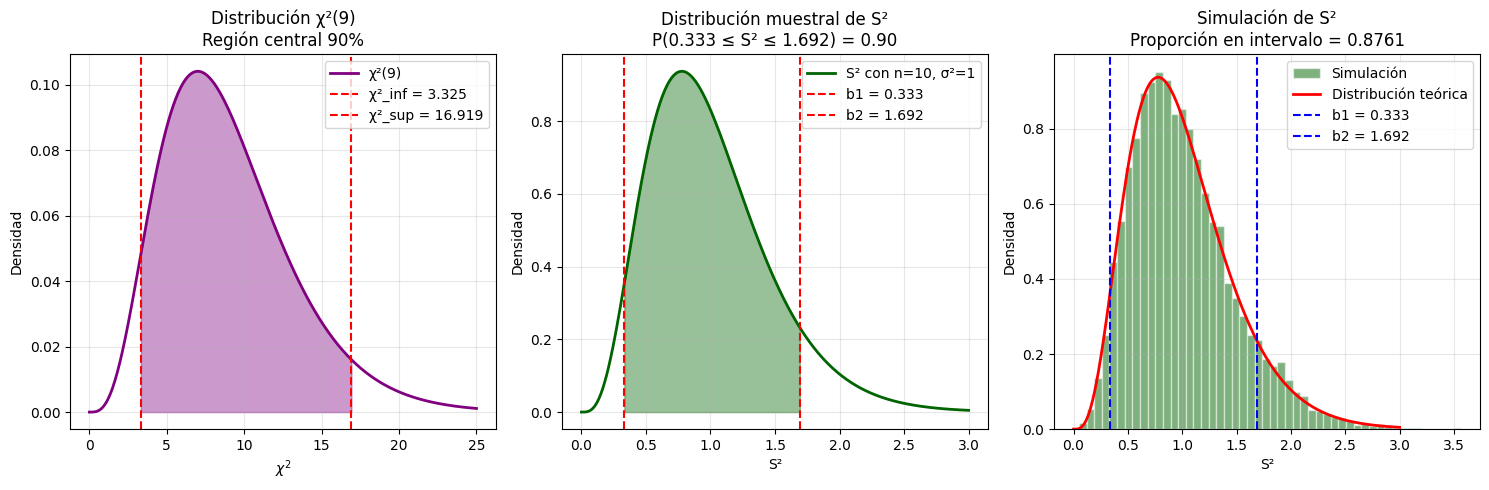

In [ ]:


# ============================================
# @title **EJEMPLO 2: DISTRIBUCIÓN MUESTRAL DE LA VARIANZA**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parámetros
n = 10
gl = n - 1  # 9 grados de libertad
confianza = 0.90

# Valor crítico inferior y superior de chi-cuadrado
chi2_inferior = chi2.ppf((1 - confianza)/2, df=gl)   # 0.05 -> 3.325
chi2_superior = chi2.ppf((1 + confianza)/2, df=gl)   # 0.95 -> 16.919

# Convertir a límites para S^2 (σ^2 = 1)
b1 = chi2_inferior / n
b2 = chi2_superior / n

print("Valores críticos de χ²(9):")
print(f"  χ²_inferior = {chi2_inferior:.4f}")
print(f"  χ²_superior = {chi2_superior:.4f}")
print("\nLímites para S²:")
print(f"  b1 = {b1:.4f}")
print(f"  b2 = {b2:.4f}")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Distribución χ²(9)
x_vals = np.linspace(0, 25, 500)
densidad = chi2.pdf(x_vals, df=gl)

axes[0].plot(x_vals, densidad, 'purple', lw=2, label=f'χ²({gl})')

# Región central (90%)
x_central = np.linspace(chi2_inferior, chi2_superior, 100)
y_central = chi2.pdf(x_central, df=gl)
axes[0].fill_between(x_central, y_central, alpha=0.4, color='purple')
axes[0].axvline(chi2_inferior, color='red', linestyle='--',
                label=f'χ²_inf = {chi2_inferior:.3f}')
axes[0].axvline(chi2_superior, color='red', linestyle='--',
                label=f'χ²_sup = {chi2_superior:.3f}')
axes[0].set_xlabel(r'$\chi^2$')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución χ²({gl})\nRegión central 90%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución de S²
x_vals_s2 = np.linspace(0, 3, 500)
densidad_s2 = chi2.pdf(x_vals_s2 * (n-1), df=gl) * (n-1)

axes[1].plot(x_vals_s2, densidad_s2, 'darkgreen', lw=2,
             label=f'S² con n={n}, σ²=1')

# Región central (90%)
x_central_s2 = np.linspace(b1, b2, 100)
y_central_s2 = chi2.pdf(x_central_s2 * (n-1), df=gl) * (n-1)
axes[1].fill_between(x_central_s2, y_central_s2, alpha=0.4, color='darkgreen')
axes[1].axvline(b1, color='red', linestyle='--', label=f'b1 = {b1:.3f}')
axes[1].axvline(b2, color='red', linestyle='--', label=f'b2 = {b2:.3f}')
axes[1].set_xlabel('S²')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Distribución muestral de S²\nP({b1:.3f} ≤ S² ≤ {b2:.3f}) = 0.90')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN DE S²
# ============================================

np.random.seed(456)
n_sim = 10000
n = 10
sigma_verdadera = 1

simulaciones_s2 = []
for _ in range(n_sim):
    muestra = np.random.normal(0, sigma_verdadera, n)
    simulaciones_s2.append(np.var(muestra, ddof=1))
simulaciones_s2 = np.array(simulaciones_s2)

# Histograma de las simulaciones
axes[2].hist(simulaciones_s2, bins=50, density=True, alpha=0.5,
             color='darkgreen', edgecolor='white', label='Simulación')

# Superponer curva teórica
axes[2].plot(x_vals_s2, densidad_s2, 'r-', lw=2, label='Distribución teórica')
axes[2].axvline(b1, color='blue', linestyle='--', label=f'b1 = {b1:.3f}')
axes[2].axvline(b2, color='blue', linestyle='--', label=f'b2 = {b2:.3f}')

# Proporción de simulaciones en el intervalo
proporcion = np.mean((simulaciones_s2 >= b1) & (simulaciones_s2 <= b2))
axes[2].set_xlabel('S²')
axes[2].set_ylabel('Densidad')
axes[2].set_title(f'Simulación de S²\nProporción en intervalo = {proporcion:.4f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T6"></a>
## **6. EJEMPLO 3: DISTRIBUCIÓN t DE STUDENT**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

P(-2 ≤ t(5) ≤ 2) = 0.8981 
P(-2 ≤ Z ≤ 2) = 0.9545 


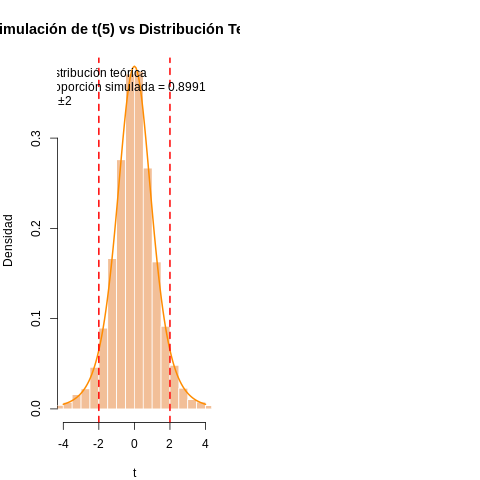

In [ ]:

# ============================================
# @title **B. EJEMPLO 3: DISTRIBUCIÓN t DE STUDENT**
# ============================================
%%R
# Parámetros
n <- 6
gl <- n - 1  # 5 grados de libertad
valor_t <- 2

# Probabilidad P(-2 ≤ t(5) ≤ 2)
probabilidad <- pt(valor_t, df = gl) - pt(-valor_t, df = gl)
cat("P(-2 ≤ t(5) ≤ 2) =", round(probabilidad, 4), "\n")

# Comparación con distribución normal
prob_normal <- pnorm(2) - pnorm(-2)
cat("P(-2 ≤ Z ≤ 2) =", round(prob_normal, 4), "\n")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN t vs NORMAL
# ============================================

# Crear secuencia de valores x
x_vals <- seq(-4, 4, length.out = 500)

# Densidades
densidad_t <- dt(x_vals, df = gl)
densidad_norm <- dnorm(x_vals)

# Región de interés (-2 a 2)
x_fill <- seq(-2, 2, length.out = 100)
y_fill_t <- dt(x_fill, df = gl)
y_fill_norm <- dnorm(x_fill)

# Gráfico comparativo
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución t
plot(x_vals, densidad_t, type = "l", lwd = 2, col = "darkorange",
     xlab = "t", ylab = "Densidad",
     main = paste("Distribución t de Student\ncon", gl, "grados de libertad"))

polygon(c(x_fill, rev(x_fill)), c(y_fill_t, rep(0, length(x_fill))),
        col = rgb(0.9, 0.5, 0.2, 0.4), border = NA)
abline(v = c(-2, 2), lty = 2, col = "red")
text(-2.5, 0.3, labels = "t = -2", col = "red")
text(2.5, 0.3, labels = "t = 2", col = "red")

legend("topright",
       legend = paste("Área =", round(probabilidad, 4)),
       fill = rgb(0.9, 0.5, 0.2, 0.4), bty = "n")

# Gráfico 2: Comparación t vs Normal
plot(x_vals, densidad_t, type = "l", lwd = 2, col = "darkorange",
     xlab = "Valor", ylab = "Densidad",
     main = "Comparación: t(5) vs Normal Estándar")
lines(x_vals, densidad_norm, col = "steelblue", lwd = 2, lty = 2)

polygon(c(x_fill, rev(x_fill)), c(y_fill_t, rep(0, length(x_fill))),
        col = rgb(0.9, 0.5, 0.2, 0.2), border = NA)
polygon(c(x_fill, rev(x_fill)), c(y_fill_norm, rep(0, length(x_fill))),
        col = rgb(0.2, 0.5, 0.8, 0.2), border = NA)

abline(v = c(-2, 2), lty = 2, col = "gray")

legend("topright",
       legend = c(paste("t(5) (área =", round(probabilidad, 4), ")"),
                  paste("Normal (área =", round(prob_normal, 4), ")")),
       col = c("darkorange", "steelblue"), lwd = 2, lty = c(1, 2), bty = "n")

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN t
# ============================================

set.seed(789)
n_sim <- 10000
gl_sim <- 5

# Simular usando la definición: t = Z / sqrt(χ²/ν)
Z_sim <- rnorm(n_sim)
chi2_sim <- rchisq(n_sim, df = gl_sim)
t_sim <- Z_sim / sqrt(chi2_sim / gl_sim)

# Histograma de las simulaciones
hist(t_sim, breaks = 50, prob = TRUE,
     col = rgb(0.9, 0.5, 0.2, 0.5), border = "white",
     main = "Simulación de t(5) vs Distribución Teórica",
     xlab = "t", ylab = "Densidad",
     xlim = c(-4, 4))

# Superponer curva teórica
curve(dt(x, df = gl_sim), add = TRUE, col = "darkorange", lwd = 2)

# Líneas en t = ±2
abline(v = c(-2, 2), col = "red", lty = 2, lwd = 2)

# Proporción de simulaciones en el intervalo
proporcion <- mean(t_sim >= -2 & t_sim <= 2)
legend("topright",
       legend = c("Distribución teórica",
                  paste("Proporción simulada =", round(proporcion, 4)),
                  "t = ±2"),
       col = c("darkorange", "red", "red"),
       lty = c(1, NA, 2), pch = c(NA, 15, NA), lwd = c(2, NA, 2), bty = "n")



P(-2 ≤ t(5) ≤ 2) = 0.8981
P(-2 ≤ Z ≤ 2) = 0.9545


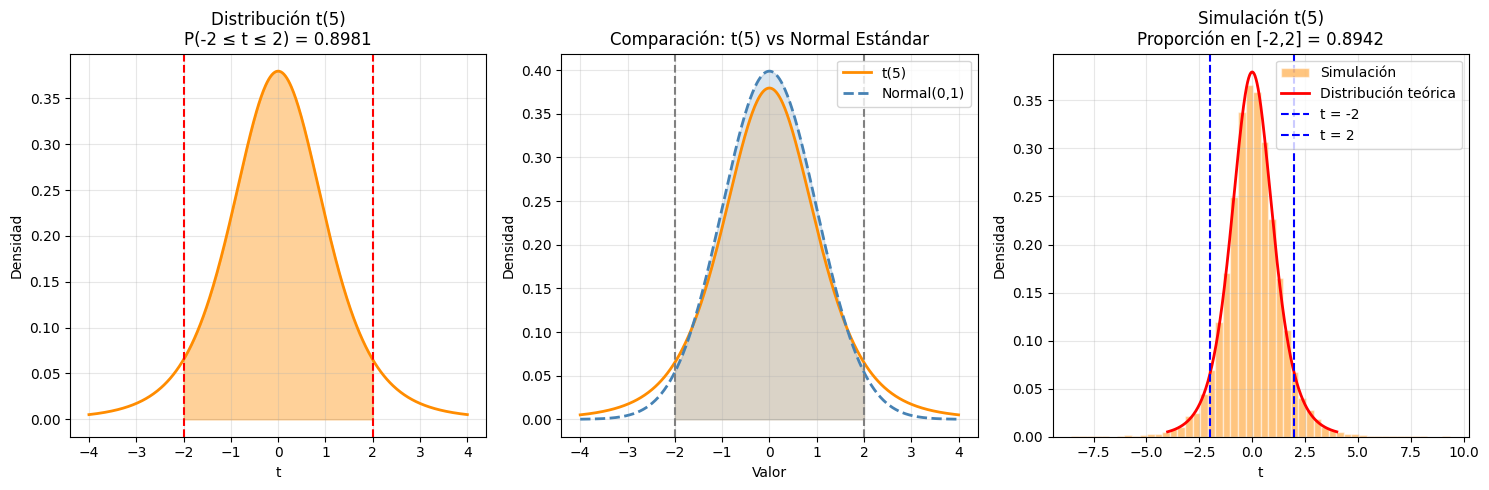

In [ ]:


# ============================================
# @title **C. EJEMPLO 3: DISTRIBUCIÓN t DE STUDENT**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Parámetros
n = 6
gl = n - 1  # 5 grados de libertad
valor_t = 2

# Probabilidad P(-2 ≤ t(5) ≤ 2)
probabilidad = t.cdf(valor_t, df=gl) - t.cdf(-valor_t, df=gl)
print(f"P(-2 ≤ t(5) ≤ 2) = {probabilidad:.4f}")

# Comparación con distribución normal
prob_normal = norm.cdf(2) - norm.cdf(-2)
print(f"P(-2 ≤ Z ≤ 2) = {prob_normal:.4f}")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN t vs NORMAL
# ============================================

x_vals = np.linspace(-4, 4, 500)
densidad_t = t.pdf(x_vals, df=gl)
densidad_norm = norm.pdf(x_vals)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Distribución t(5)
axes[0].plot(x_vals, densidad_t, 'darkorange', lw=2, label=f't({gl})')

# Región de interés (-2 a 2)
x_fill = np.linspace(-2, 2, 100)
y_fill = t.pdf(x_fill, df=gl)
axes[0].fill_between(x_fill, y_fill, alpha=0.4, color='darkorange')
axes[0].axvline(-2, color='red', linestyle='--')
axes[0].axvline(2, color='red', linestyle='--')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución t({gl})\nP(-2 ≤ t ≤ 2) = {probabilidad:.4f}')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Comparación t vs Normal
axes[1].plot(x_vals, densidad_t, 'darkorange', lw=2, label=f't({gl})')
axes[1].plot(x_vals, densidad_norm, 'steelblue', lw=2, linestyle='--',
             label='Normal(0,1)')
axes[1].fill_between(x_fill, y_fill, alpha=0.2, color='darkorange')
axes[1].fill_between(x_fill, norm.pdf(x_fill), alpha=0.2, color='steelblue')
axes[1].axvline(-2, color='gray', linestyle='--')
axes[1].axvline(2, color='gray', linestyle='--')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Comparación: t(5) vs Normal Estándar')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN t
# ============================================

np.random.seed(789)
n_sim = 10000
gl_sim = 5

# Simular usando la definición: t = Z / sqrt(χ²/ν)
Z_sim = np.random.normal(0, 1, n_sim)
chi2_sim = np.random.chisquare(gl_sim, n_sim)
t_sim = Z_sim / np.sqrt(chi2_sim / gl_sim)

# Histograma de las simulaciones
axes[2].hist(t_sim, bins=50, density=True, alpha=0.5,
             color='darkorange', edgecolor='white', label='Simulación')

# Superponer curva teórica
x_teorica = np.linspace(-4, 4, 500)
y_teorica = t.pdf(x_teorica, df=gl_sim)
axes[2].plot(x_teorica, y_teorica, 'r-', lw=2, label='Distribución teórica')

axes[2].axvline(-2, color='blue', linestyle='--', label='t = -2')
axes[2].axvline(2, color='blue', linestyle='--', label='t = 2')

# Proporción de simulaciones en el intervalo
proporcion = np.mean((t_sim >= -2) & (t_sim <= 2))
axes[2].set_xlabel('t')
axes[2].set_ylabel('Densidad')
axes[2].set_title(f'Simulación t({gl_sim})\nProporción en [-2,2] = {proporcion:.4f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T7"></a>
## **7. EJEMPLO 1: DISTRIBUCIÓN FS**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

Valor b tal que P(F(5,9) ≤ b) = 0.95: 3.4817 


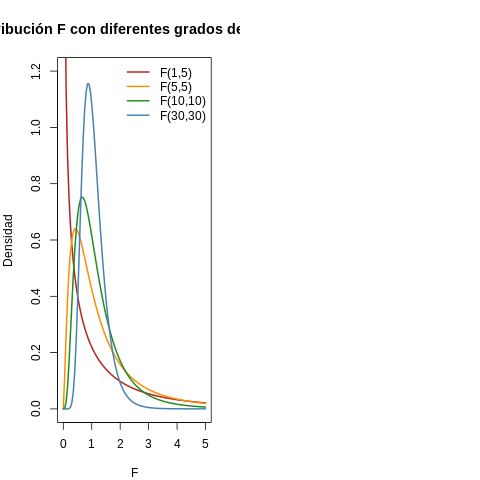

In [ ]:

# ============================================
# @title **B. EJEMPLO 1: DISTRIBUCIÓN F**
# ============================================
%%R
# Parámetros
n1 <- 6
n2 <- 10
gl1 <- n1 - 1  # 5 grados de libertad del numerador
gl2 <- n2 - 1  # 9 grados de libertad del denominador
confianza <- 0.95

# Valor crítico de F
b <- qf(confianza, df1 = gl1, df2 = gl2)
cat("Valor b tal que P(F(5,9) ≤ b) = 0.95:", round(b, 4), "\n")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN F
# ============================================

# Crear secuencia de valores x
x_vals <- seq(0, 6, length.out = 500)
densidad <- df(x_vals, df1 = gl1, df2 = gl2)

# Región de probabilidad (0 a b)
x_fill <- seq(0, b, length.out = 100)
y_fill <- df(x_fill, df1 = gl1, df2 = gl2)

# Gráfico
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución F(5,9)
plot(x_vals, densidad, type = "l", lwd = 2, col = "firebrick",
     xlab = "F", ylab = "Densidad",
     main = paste("Distribución F con", gl1, "y", gl2, "grados de libertad"))

polygon(c(x_fill, rev(x_fill)), c(y_fill, rep(0, length(x_fill))),
        col = rgb(0.8, 0.2, 0.2, 0.4), border = NA)
abline(v = b, lty = 2, col = "red", lwd = 2)
text(b + 0.2, max(densidad) * 0.8,
     labels = paste("b =", round(b, 4)), col = "red")

legend("topright", legend = paste("Área = 0.95"),
       fill = rgb(0.8, 0.2, 0.2, 0.4), bty = "n")

# ============================================
# SIMULACIÓN DEL COCIENTE DE VARIANZAS
# ============================================

set.seed(123)
n_sim <- 10000
n1_sim <- 6
n2_sim <- 10
sigma_verdadera <- 1  # varianzas iguales

# Simular muestras y calcular cociente de varianzas
simulaciones_F <- replicate(n_sim, {
  muestra1 <- rnorm(n1_sim, mean = 0, sd = sigma_verdadera)
  muestra2 <- rnorm(n2_sim, mean = 0, sd = sigma_verdadera)
  var(muestra1) / var(muestra2)
})

# Gráfico 2: Comparación simulación vs teórica
hist(simulaciones_F, breaks = 50, prob = TRUE,
     col = rgb(0.8, 0.2, 0.2, 0.5), border = "white",
     main = "Simulación de F(5,9) vs Distribución Teórica",
     xlab = "F = S₁²/S₂²", ylab = "Densidad",
     xlim = c(0, 6))

# Superponer curva teórica
curve(df(x, df1 = gl1, df2 = gl2), add = TRUE, col = "firebrick", lwd = 2)

# Línea del valor crítico
abline(v = b, col = "blue", lty = 2, lwd = 2)

# Proporción de simulaciones ≤ b
proporcion <- mean(simulaciones_F <= b)
legend("topright",
       legend = c("Distribución teórica",
                  paste("Proporción simulada =", round(proporcion, 4)),
                  paste("b =", round(b, 4))),
       col = c("firebrick", "blue", "blue"),
       lty = c(1, NA, 2), pch = c(NA, 15, NA), lwd = c(2, NA, 2), bty = "n")

# ============================================
# VISUALIZACIÓN DE DIFERENTES GRADOS DE LIBERTAD
# ============================================

# Diferentes combinaciones de grados de libertad
gl_combinaciones <- list(c(1, 5), c(5, 5), c(10, 10), c(30, 30))
colores <- c("firebrick", "darkorange", "forestgreen", "steelblue")

plot(0, 0, type = "n", xlim = c(0, 5), ylim = c(0, 1.2),
     xlab = "F", ylab = "Densidad",
     main = "Distribución F con diferentes grados de libertad")

for (i in 1:length(gl_combinaciones)) {
  gl1_i <- gl_combinaciones[[i]][1]
  gl2_i <- gl_combinaciones[[i]][2]
  curve(df(x, df1 = gl1_i, df2 = gl2_i), add = TRUE,
        col = colores[i], lwd = 2)
}

legend("topright",
       legend = c("F(1,5)", "F(5,5)", "F(10,10)", "F(30,30)"),
       col = colores, lwd = 2, bty = "n")



Valor b tal que P(F(5,9) ≤ b) = 0.95: 3.4817


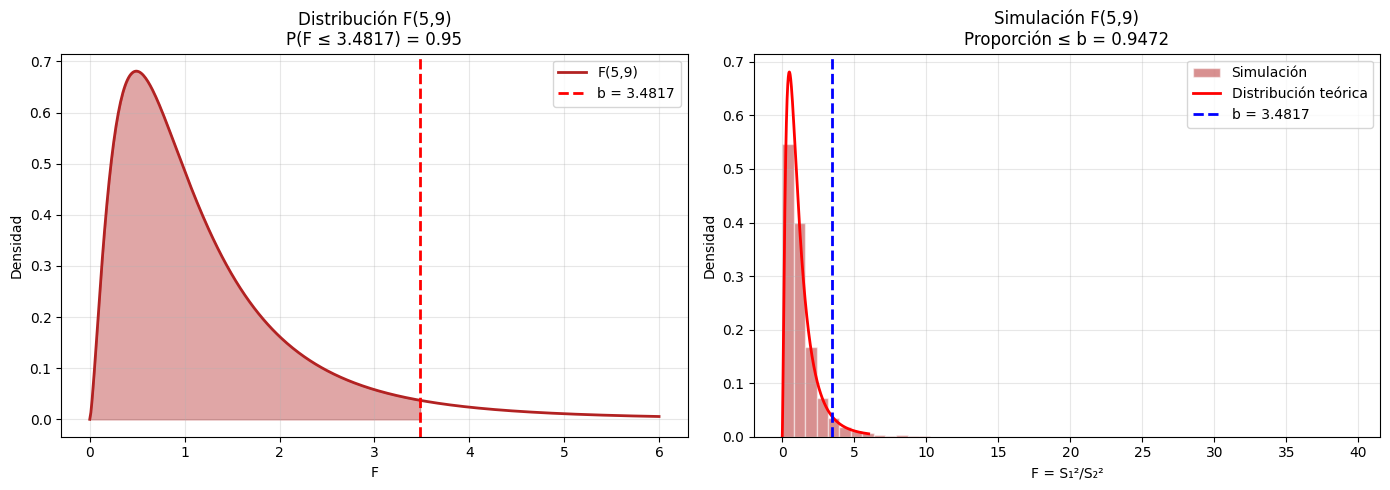

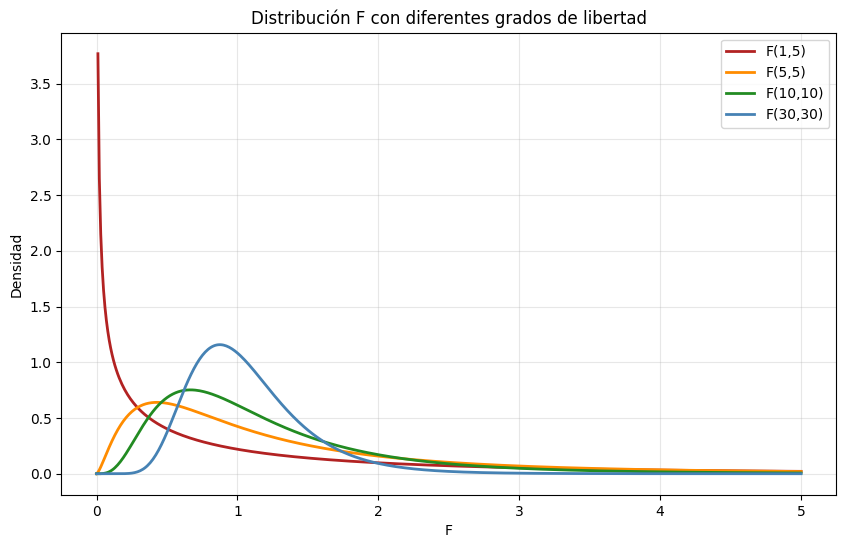

In [ ]:

# ============================================
# @title **C.  EJEMPLO 1: DISTRIBUCIÓN F**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f, norm

# Parámetros
n1 = 6
n2 = 10
gl1 = n1 - 1  # 5 grados de libertad del numerador
gl2 = n2 - 1  # 9 grados de libertad del denominador
confianza = 0.95

# Valor crítico de F
b = f.ppf(confianza, dfn=gl1, dfd=gl2)
print(f"Valor b tal que P(F(5,9) ≤ b) = 0.95: {b:.4f}")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN F
# ============================================

x_vals = np.linspace(0, 6, 500)
densidad = f.pdf(x_vals, dfn=gl1, dfd=gl2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución F(5,9)
axes[0].plot(x_vals, densidad, 'firebrick', lw=2, label=f'F({gl1},{gl2})')

# Región de probabilidad (0 a b)
x_fill = np.linspace(0, b, 100)
y_fill = f.pdf(x_fill, dfn=gl1, dfd=gl2)
axes[0].fill_between(x_fill, y_fill, alpha=0.4, color='firebrick')
axes[0].axvline(b, color='red', linestyle='--', lw=2, label=f'b = {b:.4f}')
axes[0].set_xlabel('F')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución F({gl1},{gl2})\nP(F ≤ {b:.4f}) = 0.95')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================
# SIMULACIÓN DEL COCIENTE DE VARIANZAS
# ============================================

np.random.seed(123)
n_sim = 10000
n1_sim = 6
n2_sim = 10
sigma_verdadera = 1  # varianzas iguales

simulaciones_F = []
for _ in range(n_sim):
    muestra1 = np.random.normal(0, sigma_verdadera, n1_sim)
    muestra2 = np.random.normal(0, sigma_verdadera, n2_sim)
    simulaciones_F.append(np.var(muestra1, ddof=1) / np.var(muestra2, ddof=1))
simulaciones_F = np.array(simulaciones_F)

# Gráfico 2: Comparación simulación vs teórica
axes[1].hist(simulaciones_F, bins=50, density=True, alpha=0.5,
             color='firebrick', edgecolor='white', label='Simulación')

# Superponer curva teórica
x_teorica = np.linspace(0, 6, 500)
y_teorica = f.pdf(x_teorica, dfn=gl1, dfd=gl2)
axes[1].plot(x_teorica, y_teorica, 'r-', lw=2, label='Distribución teórica')
axes[1].axvline(b, color='blue', linestyle='--', lw=2, label=f'b = {b:.4f}')

# Proporción de simulaciones ≤ b
proporcion = np.mean(simulaciones_F <= b)
axes[1].set_xlabel('F = S₁²/S₂²')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Simulación F({gl1},{gl2})\nProporción ≤ b = {proporcion:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# VISUALIZACIÓN DE DIFERENTES GRADOS DE LIBERTAD
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

gl_combinaciones = [(1, 5), (5, 5), (10, 10), (30, 30)]
colores = ['firebrick', 'darkorange', 'forestgreen', 'steelblue']
x_vals = np.linspace(0, 5, 500)

for i, (gl1_i, gl2_i) in enumerate(gl_combinaciones):
    densidad_i = f.pdf(x_vals, dfn=gl1_i, dfd=gl2_i)
    ax.plot(x_vals, densidad_i, color=colores[i], lw=2,
            label=f'F({gl1_i},{gl2_i})')

ax.set_xlabel('F')
ax.set_ylabel('Densidad')
ax.set_title('Distribución F con diferentes grados de libertad')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T8"></a>
## **8. EJEMPLO 2: TLC - COMPARACIÓN DE MEDIAS**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

Estadístico Z: -2.5 
P(Z ≤ -2.5 ) = 0.0062 
Probabilidad de obtener media ≤ 58: 0.0062 


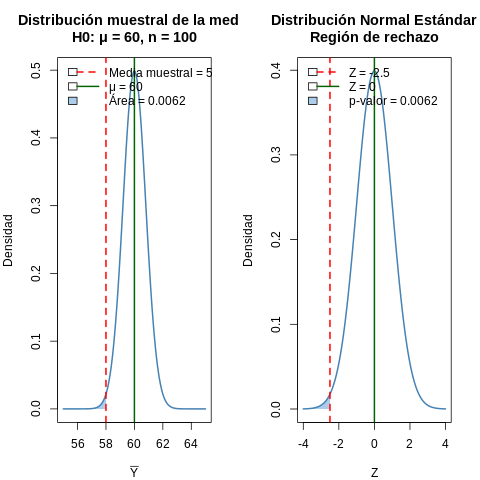

In [ ]:

# ============================================
# @title **B. EJEMPLO 2: TLC - COMPARACIÓN DE MEDIAS**
# ============================================
%%R
# Parámetros
mu_poblacional <- 60
sigma <- sqrt(64)  # 8
n <- 100
media_muestral <- 58

# Estadístico Z
error_estandar <- sigma / sqrt(n)
z <- (media_muestral - mu_poblacional) / error_estandar
p_valor <- pnorm(z)

cat("Estadístico Z:", round(z, 4), "\n")
cat("P(Z ≤", round(z, 4), ") =", round(p_valor, 4), "\n")
cat("Probabilidad de obtener media ≤ 58:", round(p_valor, 4), "\n")

# ============================================
# VISUALIZACIÓN
# ============================================

# Distribución muestral bajo H0
x_vals <- seq(55, 65, length.out = 500)
densidad <- dnorm(x_vals, mean = mu_poblacional, sd = error_estandar)

# Región crítica (media ≤ 58)
x_fill <- seq(55, media_muestral, length.out = 100)
y_fill <- dnorm(x_fill, mean = mu_poblacional, sd = error_estandar)

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución muestral
plot(x_vals, densidad, type = "l", lwd = 2, col = "steelblue",
     xlab = expression(bar(Y)), ylab = "Densidad",
     main = "Distribución muestral de la media\nH0: μ = 60, n = 100")

polygon(c(x_fill, rev(x_fill)), c(y_fill, rep(0, length(x_fill))),
        col = rgb(0.2, 0.5, 0.8, 0.4), border = NA)
abline(v = media_muestral, col = "red", lty = 2, lwd = 2)
abline(v = mu_poblacional, col = "darkgreen", lty = 1, lwd = 2)

legend("topleft",
       legend = c(paste("Media muestral =", media_muestral),
                  paste("μ =", mu_poblacional),
                  paste("Área =", round(p_valor, 4))),
       col = c("red", "darkgreen", rgb(0.2, 0.5, 0.8, 0.4)),
       lty = c(2, 1, NA), lwd = c(2, 2, NA),
       fill = c(NA, NA, rgb(0.2, 0.5, 0.8, 0.4)), bty = "n")

# Gráfico 2: Distribución normal estándar
z_vals <- seq(-4, 4, length.out = 500)
densidad_z <- dnorm(z_vals)
z_fill <- seq(-4, z, length.out = 100)
y_z_fill <- dnorm(z_fill)

plot(z_vals, densidad_z, type = "l", lwd = 2, col = "steelblue",
     xlab = "Z", ylab = "Densidad",
     main = "Distribución Normal Estándar\nRegión de rechazo")

polygon(c(z_fill, rev(z_fill)), c(y_z_fill, rep(0, length(z_fill))),
        col = rgb(0.2, 0.5, 0.8, 0.4), border = NA)
abline(v = z, col = "red", lty = 2, lwd = 2)
abline(v = 0, col = "darkgreen", lty = 1, lwd = 2)

legend("topleft",
       legend = c(paste("Z =", round(z, 4)),
                  "Z = 0",
                  paste("p-valor =", round(p_valor, 4))),
       col = c("red", "darkgreen", rgb(0.2, 0.5, 0.8, 0.4)),
       lty = c(2, 1, NA), lwd = c(2, 2, NA),
       fill = c(NA, NA, rgb(0.2, 0.5, 0.8, 0.4)), bty = "n")


Estadístico Z: -2.5000
P(Z ≤ -2.5000) = 0.0062
Probabilidad de obtener media ≤ 58: 0.0062


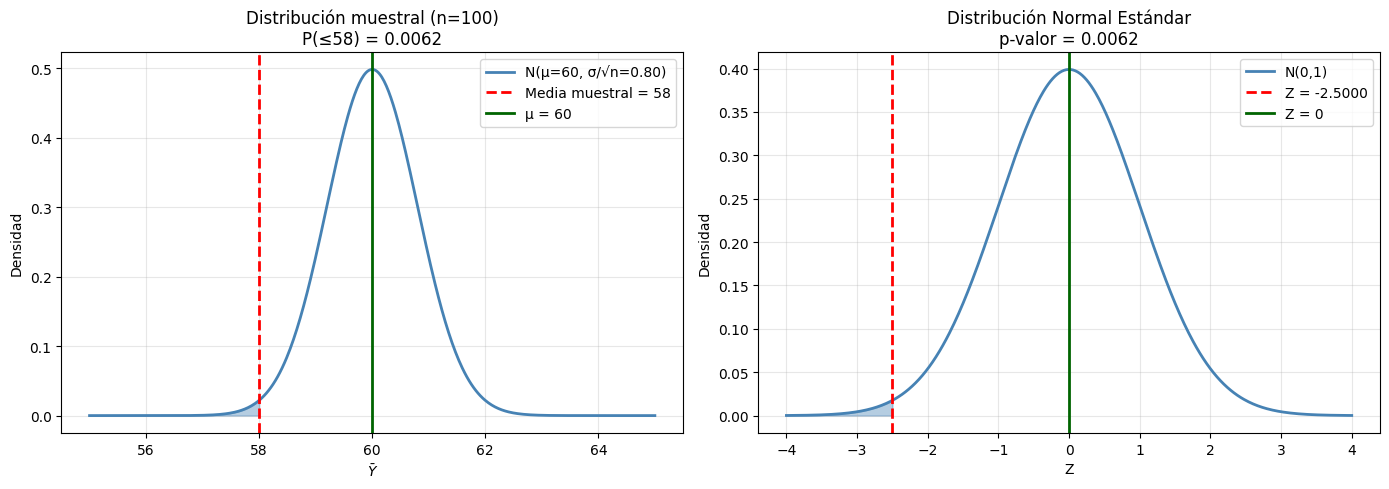

In [ ]:


# ============================================
# @title **C. EJEMPLO 2: TLC - COMPARACIÓN DE MEDIAS**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
mu_poblacional = 60
sigma = np.sqrt(64)  # 8
n = 100
media_muestral = 58

# Estadístico Z
error_estandar = sigma / np.sqrt(n)
z = (media_muestral - mu_poblacional) / error_estandar
p_valor = norm.cdf(z)

print(f"Estadístico Z: {z:.4f}")
print(f"P(Z ≤ {z:.4f}) = {p_valor:.4f}")
print(f"Probabilidad de obtener media ≤ 58: {p_valor:.4f}")

# ============================================
# VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución muestral
x_vals = np.linspace(55, 65, 500)
densidad = norm.pdf(x_vals, loc=mu_poblacional, scale=error_estandar)

axes[0].plot(x_vals, densidad, 'steelblue', lw=2,
             label=f'N(μ={mu_poblacional}, σ/√n={error_estandar:.2f})')

# Región crítica (media ≤ 58)
x_fill = np.linspace(55, media_muestral, 100)
y_fill = norm.pdf(x_fill, loc=mu_poblacional, scale=error_estandar)
axes[0].fill_between(x_fill, y_fill, alpha=0.4, color='steelblue')
axes[0].axvline(media_muestral, color='red', linestyle='--', lw=2,
                label=f'Media muestral = {media_muestral}')
axes[0].axvline(mu_poblacional, color='darkgreen', lw=2,
                label=f'μ = {mu_poblacional}')
axes[0].set_xlabel(r'$\bar{Y}$')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución muestral (n={n})\nP(≤58) = {p_valor:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución normal estándar
z_vals = np.linspace(-4, 4, 500)
densidad_z = norm.pdf(z_vals)

axes[1].plot(z_vals, densidad_z, 'steelblue', lw=2, label='N(0,1)')

# Región de rechazo
z_fill = np.linspace(-4, z, 100)
y_z_fill = norm.pdf(z_fill)
axes[1].fill_between(z_fill, y_z_fill, alpha=0.4, color='steelblue')
axes[1].axvline(z, color='red', linestyle='--', lw=2, label=f'Z = {z:.4f}')
axes[1].axvline(0, color='darkgreen', lw=2, label='Z = 0')
axes[1].set_xlabel('Z')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Distribución Normal Estándar\np-valor = {p_valor:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T9"></a>
## **9. EJEMPLO 4: APROXIMACIÓN NORMAL DE LA BINOMIAL**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== APROXIMACIÓN NORMAL ===
Estadístico Z: 1 
P(proporción ≥ 0.55) ≈ 0.1587 

=== CÁLCULO EXACTO BINOMIAL ===
P(Y ≥ 55) = 0.1841 
Diferencia: 0.025446 


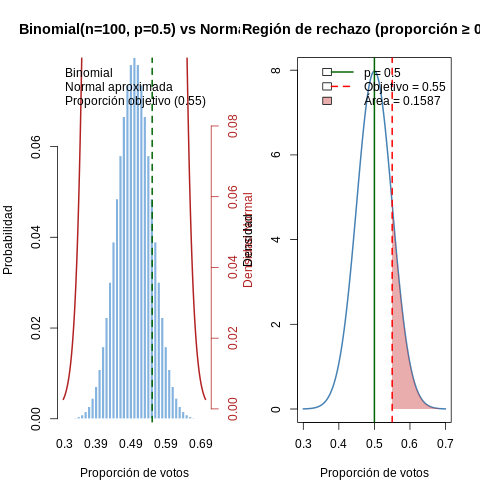

In [ ]:

# ============================================
# @title **B. EJEMPLO 4: APROXIMACIÓN NORMAL DE LA BINOMIAL**
# ============================================
%%R
# Parámetros
n <- 100
p <- 0.5
proporcion_objetivo <- 0.55

# Aproximación normal
z <- (proporcion_objetivo - p) / sqrt(p * (1 - p) / n)
prob_normal <- 1 - pnorm(z)

# Cálculo exacto binomial
prob_binomial <- 1 - pbinom(floor(proporcion_objetivo * n) - 1, size = n, prob = p)

cat("=== APROXIMACIÓN NORMAL ===\n")
cat("Estadístico Z:", round(z, 4), "\n")
cat("P(proporción ≥ 0.55) ≈", round(prob_normal, 4), "\n\n")
cat("=== CÁLCULO EXACTO BINOMIAL ===\n")
cat("P(Y ≥ 55) =", round(prob_binomial, 4), "\n")
cat("Diferencia:", round(abs(prob_normal - prob_binomial), 6), "\n")

# ============================================
# VISUALIZACIÓN
# ============================================

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Comparación Binomial vs Normal
x_vals <- 0:n
prob_bin <- dbinom(x_vals, size = n, prob = p)

# Transformación a proporciones
prop_vals <- x_vals / n

# Distribución normal aproximada
x_norm <- seq(0.3, 0.7, length.out = 500)
dens_norm <- dnorm(x_norm, mean = p, sd = sqrt(p * (1 - p) / n))

# Histograma de probabilidades binomiales
barplot(prob_bin[prop_vals >= 0.3 & prop_vals <= 0.7],
        names.arg = round(prop_vals[prop_vals >= 0.3 & prop_vals <= 0.7], 2),
        col = rgb(0.2, 0.5, 0.8, 0.6), border = "white",
        main = paste("Binomial(n=100, p=0.5) vs Normal"),
        xlab = "Proporción de votos", ylab = "Probabilidad")

# Superponer curva normal
par(new = TRUE)
plot(x_norm, dens_norm, type = "l", lwd = 2, col = "firebrick",
     xlim = c(0.3, 0.7), ylim = c(0, max(prob_bin) * 1.2),
     xlab = "", ylab = "", axes = FALSE)
axis(4, col = "firebrick", col.axis = "firebrick")
mtext("Densidad Normal", side = 4, line = 2, col = "firebrick")

abline(v = 0.55, col = "darkgreen", lty = 2, lwd = 2)
legend("topright",
       legend = c("Binomial", "Normal aproximada", "Proporción objetivo (0.55)"),
       col = c(rgb(0.2, 0.5, 0.8, 0.6), "firebrick", "darkgreen"),
       lty = c(NA, 1, 2), lwd = c(NA, 2, 2),
       pch = c(15, NA, NA), bty = "n")

# Gráfico 2: Región de rechazo en Normal
x_norm_full <- seq(0.3, 0.7, length.out = 500)
dens_norm_full <- dnorm(x_norm_full, mean = p, sd = sqrt(p * (1 - p) / n))

plot(x_norm_full, dens_norm_full, type = "l", lwd = 2, col = "steelblue",
     xlab = "Proporción de votos", ylab = "Densidad",
     main = "Región de rechazo (proporción ≥ 0.55)")

# Región de rechazo
x_rechazo <- seq(proporcion_objetivo, 0.7, length.out = 100)
y_rechazo <- dnorm(x_rechazo, mean = p, sd = sqrt(p * (1 - p) / n))
polygon(c(x_rechazo, rev(x_rechazo)), c(y_rechazo, rep(0, length(x_rechazo))),
        col = rgb(0.8, 0.2, 0.2, 0.4), border = NA)

abline(v = proporcion_objetivo, col = "red", lty = 2, lwd = 2)
abline(v = p, col = "darkgreen", lty = 1, lwd = 2)

legend("topright",
       legend = c(paste("p =", p),
                  paste("Objetivo =", proporcion_objetivo),
                  paste("Área =", round(prob_normal, 4))),
       col = c("darkgreen", "red", rgb(0.8, 0.2, 0.2, 0.4)),
       lty = c(1, 2, NA), lwd = c(2, 2, NA),
       fill = c(NA, NA, rgb(0.8, 0.2, 0.2, 0.4)), bty = "n")



=== APROXIMACIÓN NORMAL ===
Estadístico Z: 1.0000
P(proporción ≥ 0.55) ≈ 0.1587

=== CÁLCULO EXACTO BINOMIAL ===
P(Y ≥ 55) = 0.1841
Diferencia: 0.025446


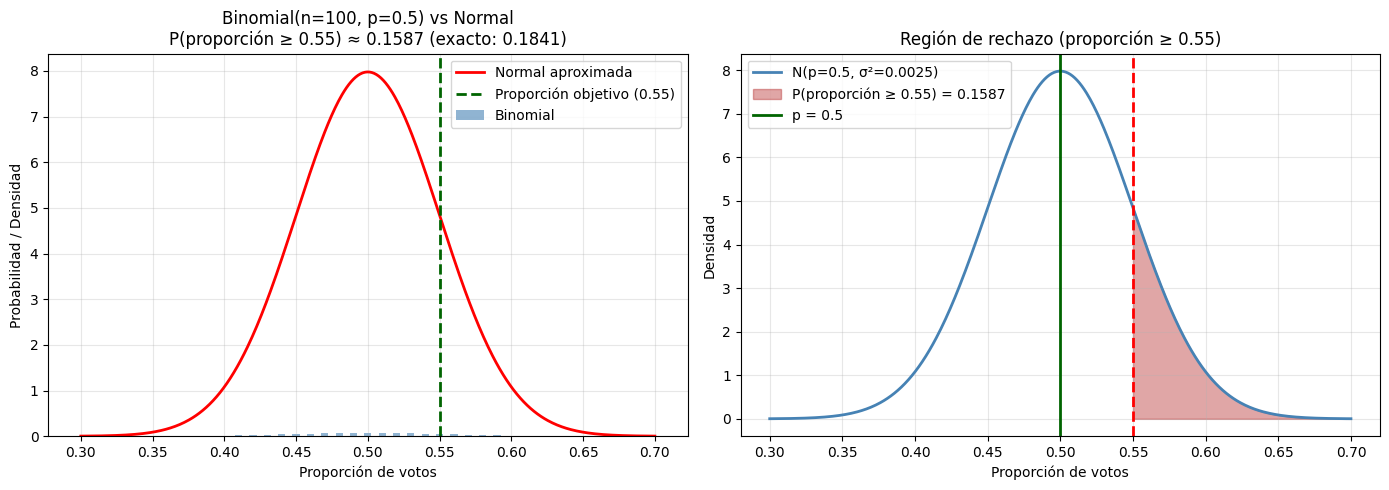

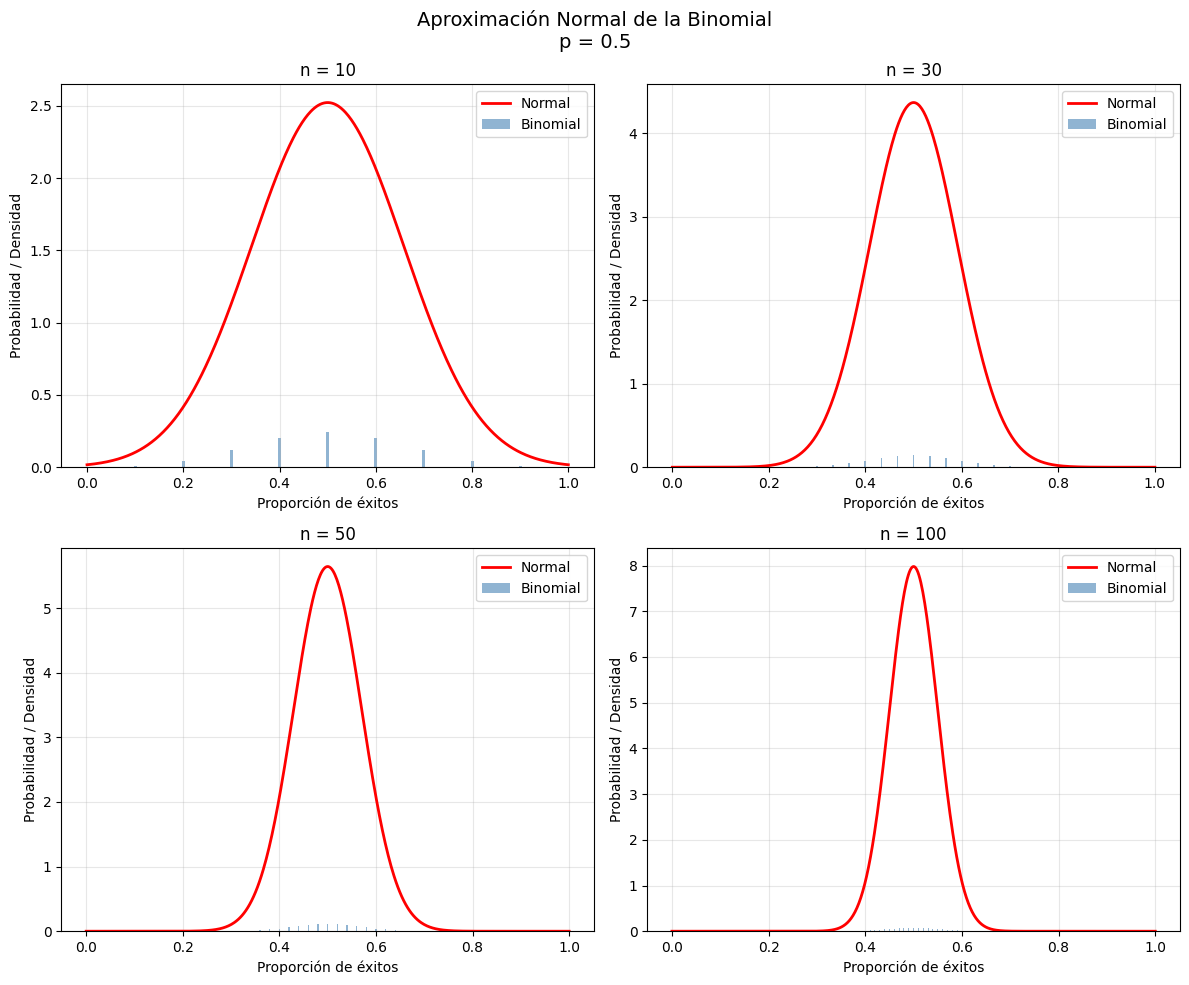

In [ ]:
# ============================================
# @title **C. EJEMPLO 4: APROXIMACIÓN NORMAL DE LA BINOMIAL**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

# Parámetros
n = 100
p = 0.5
proporcion_objetivo = 0.55

# Aproximación normal
z = (proporcion_objetivo - p) / np.sqrt(p * (1 - p) / n)
prob_normal = 1 - norm.cdf(z)

# Cálculo exacto binomial
prob_binomial = 1 - binom.cdf(int(proporcion_objetivo * n) - 1, n, p)

print("=== APROXIMACIÓN NORMAL ===")
print(f"Estadístico Z: {z:.4f}")
print(f"P(proporción ≥ 0.55) ≈ {prob_normal:.4f}")
print("\n=== CÁLCULO EXACTO BINOMIAL ===")
print(f"P(Y ≥ 55) = {prob_binomial:.4f}")
print(f"Diferencia: {abs(prob_normal - prob_binomial):.6f}")

# ============================================
# VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparación Binomial vs Normal
x_vals = np.arange(0, n+1)
prob_bin = binom.pmf(x_vals, n, p)
prop_vals = x_vals / n

# Seleccionar rango de interés
mask = (prop_vals >= 0.3) & (prop_vals <= 0.7)
axes[0].bar(prop_vals[mask], prob_bin[mask], width=0.005,
            color='steelblue', alpha=0.6, label='Binomial')

# Distribución normal aproximada
x_norm = np.linspace(0.3, 0.7, 500)
dens_norm = norm.pdf(x_norm, loc=p, scale=np.sqrt(p*(1-p)/n))
axes[0].plot(x_norm, dens_norm, 'r-', lw=2, label='Normal aproximada')
axes[0].axvline(proporcion_objetivo, color='darkgreen', linestyle='--',
                lw=2, label='Proporción objetivo (0.55)')
axes[0].set_xlabel('Proporción de votos')
axes[0].set_ylabel('Probabilidad / Densidad')
axes[0].set_title(f'Binomial(n={n}, p={p}) vs Normal\n'
                  f'P(proporción ≥ 0.55) ≈ {prob_normal:.4f} (exacto: {prob_binomial:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Región de rechazo en Normal
x_norm_full = np.linspace(0.3, 0.7, 500)
dens_norm_full = norm.pdf(x_norm_full, loc=p, scale=np.sqrt(p*(1-p)/n))

axes[1].plot(x_norm_full, dens_norm_full, 'steelblue', lw=2,
             label=f'N(p={p}, σ²={p*(1-p)/n:.4f})')

# Región de rechazo
x_rechazo = np.linspace(proporcion_objetivo, 0.7, 100)
y_rechazo = norm.pdf(x_rechazo, loc=p, scale=np.sqrt(p*(1-p)/n))
axes[1].fill_between(x_rechazo, y_rechazo, alpha=0.4, color='firebrick',
                      label=f'P(proporción ≥ {proporcion_objetivo}) = {prob_normal:.4f}')
axes[1].axvline(proporcion_objetivo, color='red', linestyle='--', lw=2)
axes[1].axvline(p, color='darkgreen', lw=2, label=f'p = {p}')
axes[1].set_xlabel('Proporción de votos')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Región de rechazo (proporción ≥ 0.55)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# DEMOSTRACIÓN DE LA APROXIMACIÓN
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

n_values = [10, 30, 50, 100]
p_value = 0.5

for idx, n_val in enumerate(n_values):
    x_vals = np.arange(0, n_val+1)
    prob_bin = binom.pmf(x_vals, n_val, p_value)
    prop_vals = x_vals / n_val

    axes[idx].bar(prop_vals, prob_bin, width=0.02/np.sqrt(n_val),
                  color='steelblue', alpha=0.6, label='Binomial')

    x_norm = np.linspace(0, 1, 500)
    dens_norm = norm.pdf(x_norm, loc=p_value,
                          scale=np.sqrt(p_value*(1-p_value)/n_val))
    axes[idx].plot(x_norm, dens_norm, 'r-', lw=2, label='Normal')

    axes[idx].set_xlabel('Proporción de éxitos')
    axes[idx].set_ylabel('Probabilidad / Densidad')
    axes[idx].set_title(f'n = {n_val}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Aproximación Normal de la Binomial\np = 0.5', fontsize=14)
plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T10"></a>
## **10. EJEMPLO 1: ESTIMADORES DE LA VARIANZA**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== RESULTADOS DE LA SIMULACIÓN ===
Varianza poblacional verdadera σ²: 225 
Media de S² (insesgado): 225.65 
Media de S*² (sesgado): 218.13 
Sesgo de S*²: -6.87 


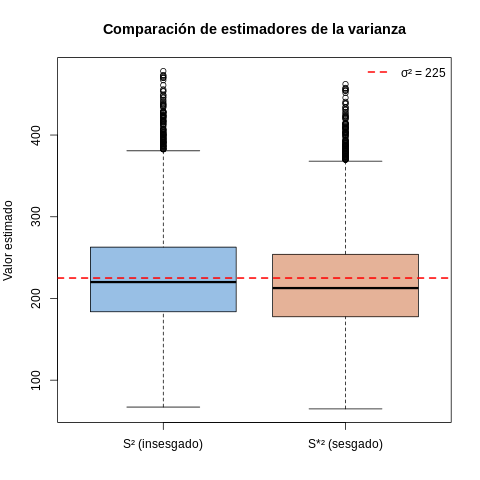

In [ ]:

# ============================================
# @title **B.  EJEMPLO 1: ESTIMADORES DE LA VARIANZA**
# ============================================
%%R

# Parámetros
set.seed(123)
n <- 30
mu_verdadera <- 100
sigma_verdadera <- 15
n_sim <- 10000

# Simulación para comparar estimadores
simulacion_varianzas <- replicate(n_sim, {
  muestra <- rnorm(n, mean = mu_verdadera, sd = sigma_verdadera)
  S2 <- var(muestra)                    # Insesgado (n-1)
  S2_sesgado <- mean((muestra - mean(muestra))^2)  # Sesgado (n)
  c(S2, S2_sesgado)
})

# Resultados
media_S2 <- mean(simulacion_varianzas[1, ])
media_S2_sesgado <- mean(simulacion_varianzas[2, ])

cat("=== RESULTADOS DE LA SIMULACIÓN ===\n")
cat("Varianza poblacional verdadera σ²:", sigma_verdadera^2, "\n")
cat("Media de S² (insesgado):", round(media_S2, 2), "\n")
cat("Media de S*² (sesgado):", round(media_S2_sesgado, 2), "\n")
cat("Sesgo de S*²:", round(media_S2_sesgado - sigma_verdadera^2, 2), "\n")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN DE LOS ESTIMADORES
# ============================================

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Histograma de S² (insesgado)
hist(simulacion_varianzas[1, ], breaks = 50, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Distribución de S² (insesgado)",
     xlab = "S²", ylab = "Densidad")
abline(v = sigma_verdadera^2, col = "red", lwd = 2, lty = 2)
abline(v = media_S2, col = "darkgreen", lwd = 2)
legend("topright",
       legend = c(paste("σ² =", sigma_verdadera^2),
                  paste("E(S²) =", round(media_S2, 2))),
       col = c("red", "darkgreen"), lty = c(2, 1), lwd = 2, bty = "n")

# Histograma de S*² (sesgado)
hist(simulacion_varianzas[2, ], breaks = 50, prob = TRUE,
     col = rgb(0.8, 0.4, 0.2, 0.5), border = "white",
     main = "Distribución de S*² (sesgado)",
     xlab = "S*²", ylab = "Densidad")
abline(v = sigma_verdadera^2, col = "red", lwd = 2, lty = 2)
abline(v = media_S2_sesgado, col = "darkgreen", lwd = 2)
legend("topright",
       legend = c(paste("σ² =", sigma_verdadera^2),
                  paste("E(S*²) =", round(media_S2_sesgado, 2))),
       col = c("red", "darkgreen"), lty = c(2, 1), lwd = 2, bty = "n")

# Gráfico comparativo de sesgo
par(mfrow = c(1, 1))
boxplot(simulacion_varianzas[1, ], simulacion_varianzas[2, ],
        names = c("S² (insesgado)", "S*² (sesgado)"),
        col = c(rgb(0.2, 0.5, 0.8, 0.5), rgb(0.8, 0.4, 0.2, 0.5)),
        main = "Comparación de estimadores de la varianza",
        ylab = "Valor estimado")
abline(h = sigma_verdadera^2, col = "red", lwd = 2, lty = 2)
legend("topright", legend = paste("σ² =", sigma_verdadera^2),
       col = "red", lty = 2, lwd = 2, bty = "n")



=== RESULTADOS DE LA SIMULACIÓN ===
Varianza poblacional verdadera σ²: 225
Media de S² (insesgado): 224.18
Media de S*² (sesgado): 216.70
Sesgo de S*²: -8.30


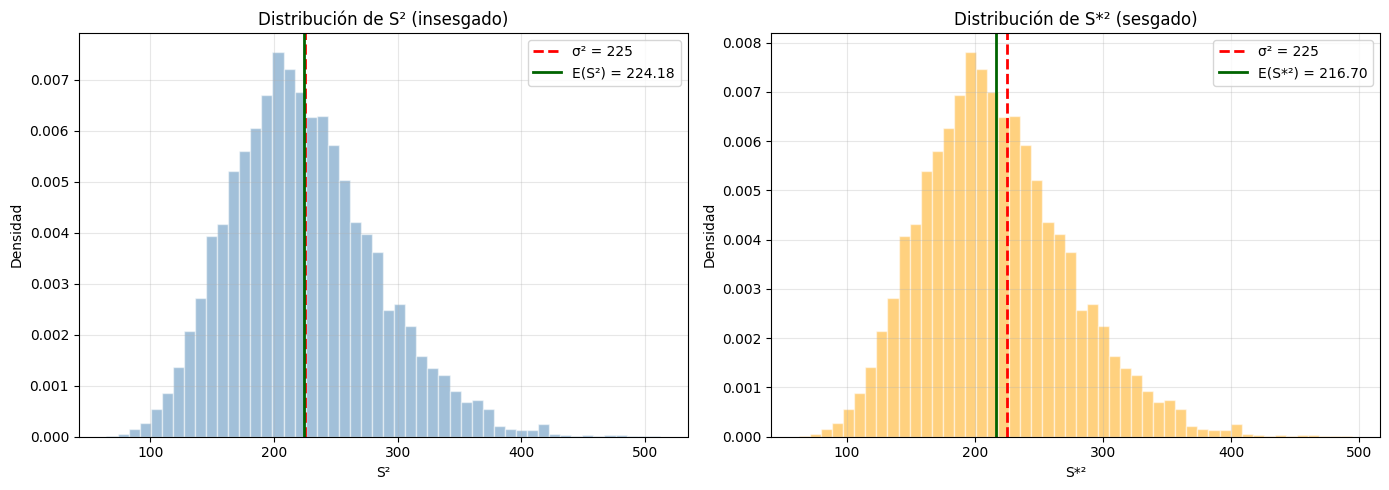

/tmp/ipykernel_1420/1797273884.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([simulacion_S2, simulacion_S2_sesgado],


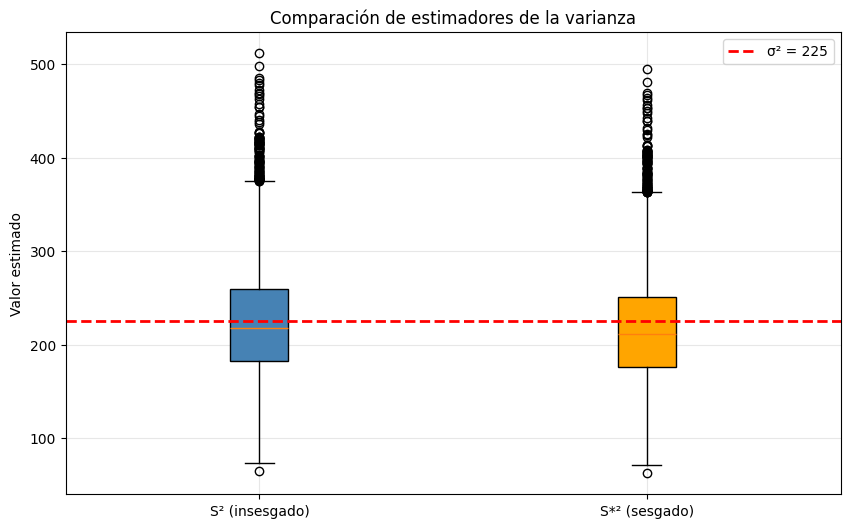

In [ ]:

# ============================================
# @title **C. EJEMPLO 1: ESTIMADORES DE LA VARIANZA**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
np.random.seed(123)
n = 30
mu_verdadera = 100
sigma_verdadera = 15
n_sim = 10000

# Simulación para comparar estimadores
simulacion_S2 = []
simulacion_S2_sesgado = []

for _ in range(n_sim):
    muestra = np.random.normal(mu_verdadera, sigma_verdadera, n)
    S2 = np.var(muestra, ddof=1)           # Insesgado (n-1)
    S2_sesgado = np.var(muestra, ddof=0)   # Sesgado (n)
    simulacion_S2.append(S2)
    simulacion_S2_sesgado.append(S2_sesgado)

# Resultados
media_S2 = np.mean(simulacion_S2)
media_S2_sesgado = np.mean(simulacion_S2_sesgado)

print("=== RESULTADOS DE LA SIMULACIÓN ===")
print(f"Varianza poblacional verdadera σ²: {sigma_verdadera**2}")
print(f"Media de S² (insesgado): {media_S2:.2f}")
print(f"Media de S*² (sesgado): {media_S2_sesgado:.2f}")
print(f"Sesgo de S*²: {media_S2_sesgado - sigma_verdadera**2:.2f}")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN DE LOS ESTIMADORES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Histograma de S² (insesgado)
axes[0].hist(simulacion_S2, bins=50, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')
axes[0].axvline(sigma_verdadera**2, color='red', linestyle='--',
                lw=2, label=f'σ² = {sigma_verdadera**2}')
axes[0].axvline(media_S2, color='darkgreen', lw=2,
                label=f'E(S²) = {media_S2:.2f}')
axes[0].set_xlabel('S²')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de S² (insesgado)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Histograma de S*² (sesgado)
axes[1].hist(simulacion_S2_sesgado, bins=50, density=True, alpha=0.5,
             color='orange', edgecolor='white')
axes[1].axvline(sigma_verdadera**2, color='red', linestyle='--',
                lw=2, label=f'σ² = {sigma_verdadera**2}')
axes[1].axvline(media_S2_sesgado, color='darkgreen', lw=2,
                label=f'E(S*²) = {media_S2_sesgado:.2f}')
axes[1].set_xlabel('S*²')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de S*² (sesgado)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico comparativo de sesgo
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([simulacion_S2, simulacion_S2_sesgado],
                labels=['S² (insesgado)', 'S*² (sesgado)'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('orange')
ax.axhline(sigma_verdadera**2, color='red', linestyle='--',
           lw=2, label=f'σ² = {sigma_verdadera**2}')
ax.set_ylabel('Valor estimado')
ax.set_title('Comparación de estimadores de la varianza')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


[⬆️ Volver al inicio](#inicio2)

<a name="T11"></a>
## **11. Visualización de la consistencia del estimador de la media**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

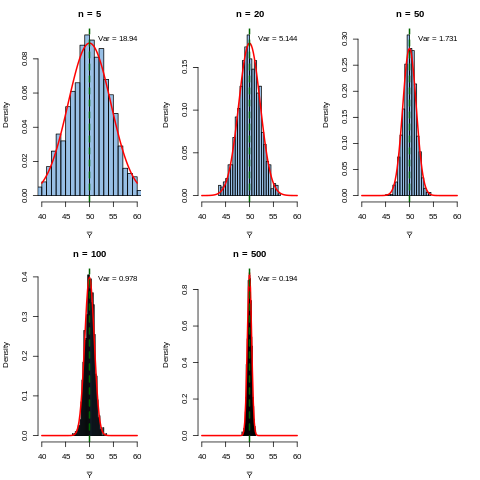

In [ ]:

# @title **B. Visualización de la consistencia del estimador de la media**
%%R
set.seed(123)
n_values <- c(5, 20, 50, 100, 500)
n_sim <- 1000
mu_verdadera <- 50
sigma <- 10

par(mfrow = c(2, 3), mar = c(4, 4, 3, 2))

for (n in n_values) {
  medias <- replicate(n_sim, mean(rnorm(n, mu_verdadera, sigma)))

  hist(medias, breaks = 30, prob = TRUE,
       main = paste("n =", n),
       xlab = expression(bar(Y)),
       col = rgb(0.2, 0.5, 0.8, 0.5),
       xlim = c(40, 60))

  curve(dnorm(x, mu_verdadera, sigma/sqrt(n)),
        add = TRUE, col = "red", lwd = 2)
  abline(v = mu_verdadera, col = "darkgreen", lwd = 2, lty = 2)

  var_estimada <- var(medias)
  legend("topright",
         legend = paste("Var =", round(var_estimada, 3)),
         bty = "n")
}

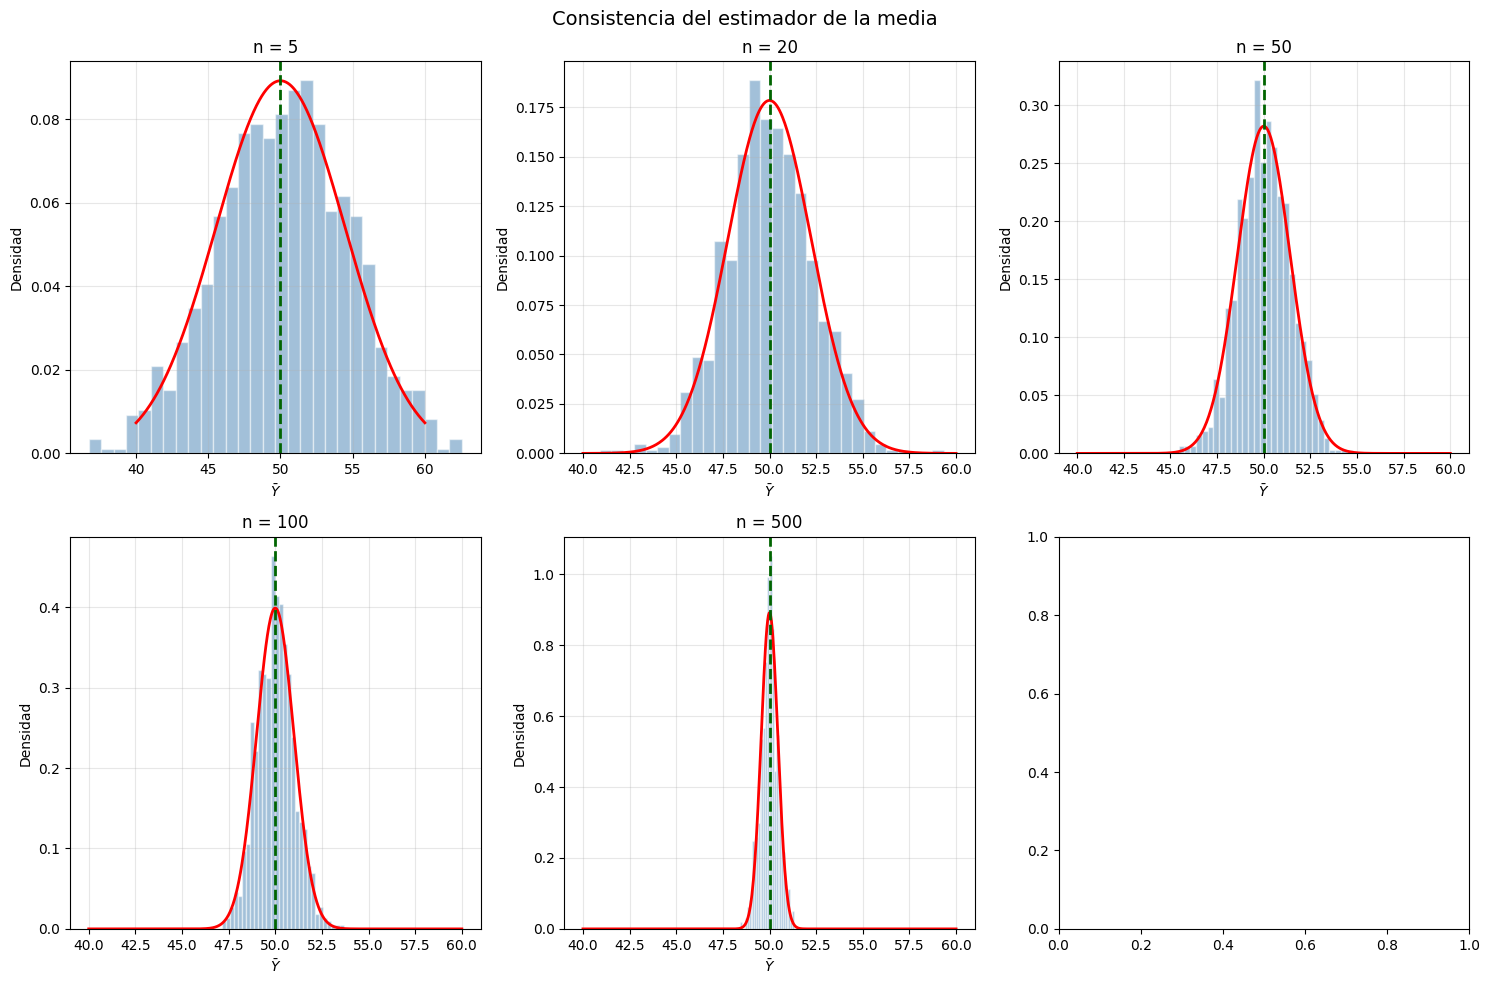

In [ ]:

# @title **C.  Visualización de la consistencia en Python**

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(123)
n_values = [5, 20, 50, 100, 500]
n_sim = 1000
mu_verdadera = 50
sigma = 10

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, n in enumerate(n_values):
    medias = [np.mean(np.random.normal(mu_verdadera, sigma, n))
              for _ in range(n_sim)]

    axes[idx].hist(medias, bins=30, density=True, alpha=0.5,
                   color='steelblue', edgecolor='white')

    x_vals = np.linspace(40, 60, 500)
    y_vals = norm.pdf(x_vals, mu_verdadera, sigma/np.sqrt(n))
    axes[idx].plot(x_vals, y_vals, 'r-', lw=2)
    axes[idx].axvline(mu_verdadera, color='darkgreen',
                      linestyle='--', lw=2)
    axes[idx].set_title(f'n = {n}')
    axes[idx].set_xlabel(r'$\bar{Y}$')
    axes[idx].set_ylabel('Densidad')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Consistencia del estimador de la media', fontsize=14)
plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T12"></a>
## **12. Comparación de eficiencia entre media y mediana**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

Varianza de la media: 0.03221 
Varianza de la mediana: 0.05052 
Eficiencia relativa (media/mediana): 0.6375 
La media es más eficiente (menor varianza) que la mediana


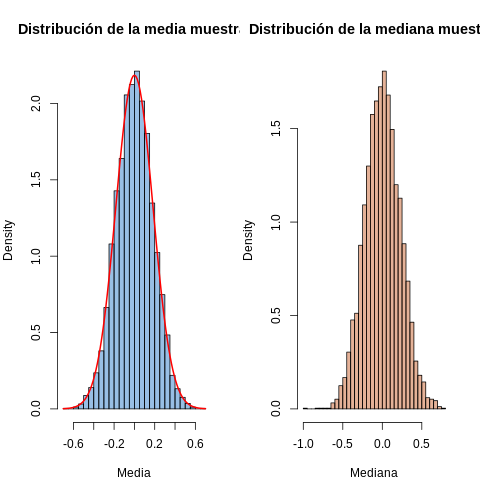

In [ ]:

# @title **B. Comparación de eficiencia entre media y mediana**
%%R

set.seed(123)
n <- 30
n_sim <- 5000
mu_verdadera <- 0
sigma <- 1

medias <- replicate(n_sim, mean(rnorm(n, mu_verdadera, sigma)))
medianas <- replicate(n_sim, median(rnorm(n, mu_verdadera, sigma)))

var_media <- var(medias)
var_mediana <- var(medianas)
eficiencia <- var_media / var_mediana

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

hist(medias, breaks = 40, prob = TRUE,
     main = "Distribución de la media muestral",
     xlab = "Media", col = rgb(0.2, 0.5, 0.8, 0.5))
curve(dnorm(x, mu_verdadera, sigma/sqrt(n)), add = TRUE,
      col = "red", lwd = 2)

hist(medianas, breaks = 40, prob = TRUE,
     main = "Distribución de la mediana muestral",
     xlab = "Mediana", col = rgb(0.8, 0.4, 0.2, 0.5))

cat("Varianza de la media:", round(var_media, 5), "\n")
cat("Varianza de la mediana:", round(var_mediana, 5), "\n")
cat("Eficiencia relativa (media/mediana):", round(eficiencia, 4), "\n")
cat("La media es más eficiente (menor varianza) que la mediana\n")


Varianza de la media: 0.03421
Varianza de la mediana: 0.05029
Eficiencia relativa (media/mediana): 0.6802
La media es más eficiente (menor varianza) que la mediana


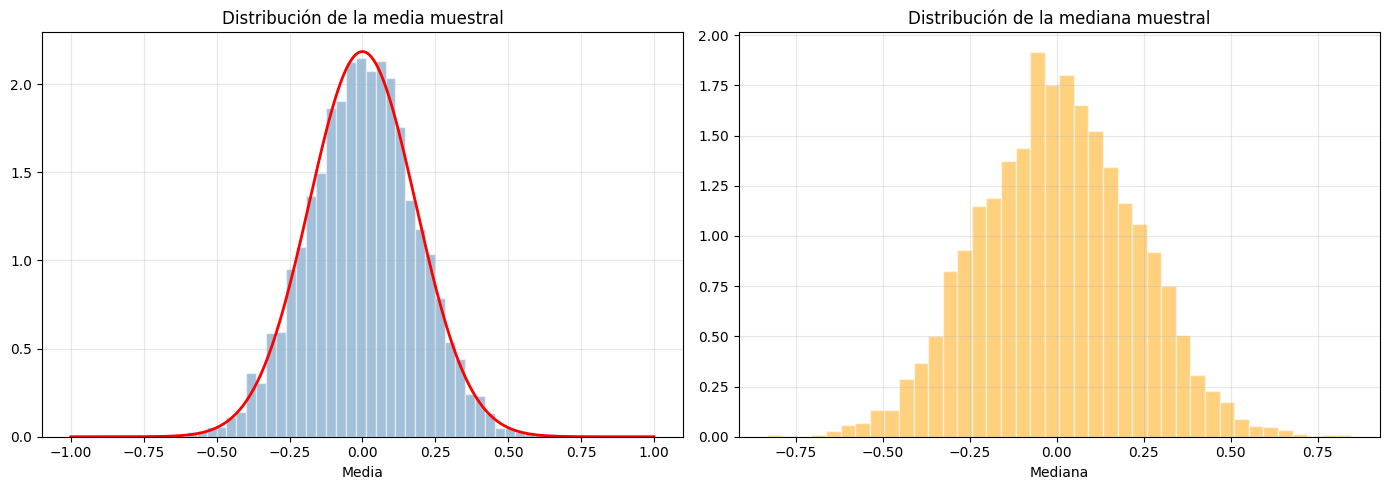

In [ ]:

# @title **C. Comparación de eficiencia en Python**

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(123)
n = 30
n_sim = 5000
mu_verdadera = 0
sigma = 1

medias = [np.mean(np.random.normal(mu_verdadera, sigma, n))
          for _ in range(n_sim)]
medianas = [np.median(np.random.normal(mu_verdadera, sigma, n))
            for _ in range(n_sim)]

var_media = np.var(medias)
var_mediana = np.var(medianas)
eficiencia = var_media / var_mediana

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(medias, bins=40, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')
x_vals = np.linspace(-1, 1, 500)
axes[0].plot(x_vals, norm.pdf(x_vals, mu_verdadera, sigma/np.sqrt(n)),
             'r-', lw=2)
axes[0].set_title('Distribución de la media muestral')
axes[0].set_xlabel('Media')
axes[0].grid(True, alpha=0.3)

axes[1].hist(medianas, bins=40, density=True, alpha=0.5,
             color='orange', edgecolor='white')
axes[1].set_title('Distribución de la mediana muestral')
axes[1].set_xlabel('Mediana')
axes[1].grid(True, alpha=0.3)

print(f"Varianza de la media: {var_media:.5f}")
print(f"Varianza de la mediana: {var_mediana:.5f}")
print(f"Eficiencia relativa (media/mediana): {eficiencia:.4f}")
print("La media es más eficiente (menor varianza) que la mediana")

plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T13"></a>
## **13. EJEMPLO 2: ESTIMACIÓN DE PROPORCIÓN**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== ESTIMACIÓN DE PROPORCIÓN ===
Tamaño de muestra (n): 1000 
Votos a favor (y): 560 
Proporción estimada (p̂): 0.56 
Error estándar (σ_p̂): 0.0157 
Límite de 2σ: 0.0314 
IC aproximado del 95%: [ 0.5286 , 0.5914 ]


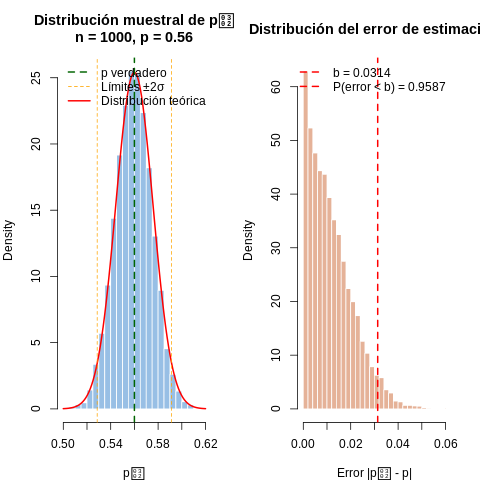

In [ ]:

# ============================================
# @title **B.  EJEMPLO 2: ESTIMACIÓN DE PROPORCIÓN**
# ============================================

%%R
# Parámetros
n <- 1000
y <- 560
p_hat <- y / n
q_hat <- 1 - p_hat

# Error estándar
se <- sqrt(p_hat * q_hat / n)
b <- 2 * se

cat("=== ESTIMACIÓN DE PROPORCIÓN ===\n")
cat("Tamaño de muestra (n):", n, "\n")
cat("Votos a favor (y):", y, "\n")
cat("Proporción estimada (p̂):", round(p_hat, 4), "\n")
cat("Error estándar (σ_p̂):", round(se, 4), "\n")
cat("Límite de 2σ:", round(b, 4), "\n")
cat("IC aproximado del 95%: [", round(p_hat - b, 4), ",", round(p_hat + b, 4), "]\n")

# ============================================
# SIMULACIÓN Y VISUALIZACIÓN
# ============================================

set.seed(123)
n_sim <- 10000
p_verdadero <- 0.56  # Valor simulado

# Simulación de proporciones muestrales
proporciones <- replicate(n_sim, rbinom(1, n, p_verdadero) / n)

# Visualización
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Histograma de la distribución muestral
hist(proporciones, breaks = 40, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Distribución muestral de p̂\nn = 1000, p = 0.56",
     xlab = "p̂", xlim = c(0.5, 0.62))

# Curva normal teórica
x_vals <- seq(0.5, 0.62, length.out = 500)
curve(dnorm(x, p_verdadero, se), add = TRUE, col = "red", lwd = 2)

# Límites de error
abline(v = p_verdadero, col = "darkgreen", lwd = 2, lty = 2)
abline(v = p_verdadero + b, col = "orange", lty = 2)
abline(v = p_verdadero - b, col = "orange", lty = 2)

legend("topright",
       legend = c("p verdadero", "Límites ±2σ", "Distribución teórica"),
       col = c("darkgreen", "orange", "red"),
       lty = c(2, 2, 1), lwd = c(2, 1, 2), bty = "n")

# Gráfico de error de estimación
errores <- abs(proporciones - p_verdadero)
hist(errores, breaks = 40, prob = TRUE,
     col = rgb(0.8, 0.4, 0.2, 0.5), border = "white",
     main = "Distribución del error de estimación",
     xlab = "Error |p̂ - p|")
abline(v = b, col = "red", lwd = 2, lty = 2)

prob_menor_b <- mean(errores < b)
legend("topright",
       legend = c(paste("b =", round(b, 4)),
                  paste("P(error < b) =", round(prob_menor_b, 4))),
       col = "red", lty = 2, lwd = 2, bty = "n")



=== ESTIMACIÓN DE PROPORCIÓN ===
Tamaño de muestra (n): 1000
Votos a favor (y): 560
Proporción estimada (p̂): 0.5600
Error estándar (σ_p̂): 0.0157
Límite de 2σ: 0.0314
IC aproximado del 95%: [0.5286, 0.5914]


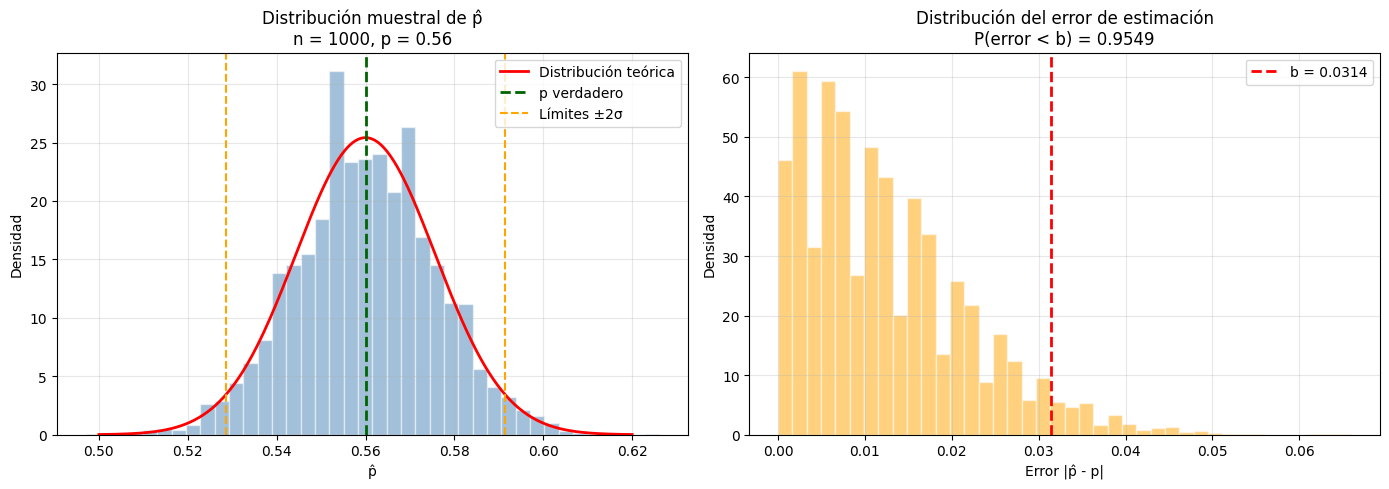

In [ ]:

# ============================================
# @title **C. EJEMPLO 2: ESTIMACIÓN DE PROPORCIÓN**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

# Parámetros
n = 1000
y = 560
p_hat = y / n
q_hat = 1 - p_hat

# Error estándar
se = np.sqrt(p_hat * q_hat / n)
b = 2 * se

print("=== ESTIMACIÓN DE PROPORCIÓN ===")
print(f"Tamaño de muestra (n): {n}")
print(f"Votos a favor (y): {y}")
print(f"Proporción estimada (p̂): {p_hat:.4f}")
print(f"Error estándar (σ_p̂): {se:.4f}")
print(f"Límite de 2σ: {b:.4f}")
print(f"IC aproximado del 95%: [{p_hat - b:.4f}, {p_hat + b:.4f}]")

# ============================================
# SIMULACIÓN Y VISUALIZACIÓN
# ============================================

np.random.seed(123)
n_sim = 10000
p_verdadero = 0.56  # Valor simulado

# Simulación de proporciones muestrales
proporciones = np.random.binomial(n, p_verdadero, n_sim) / n

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución muestral de p̂
axes[0].hist(proporciones, bins=40, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')

x_vals = np.linspace(0.5, 0.62, 500)
y_vals = norm.pdf(x_vals, p_verdadero, se)
axes[0].plot(x_vals, y_vals, 'r-', lw=2, label='Distribución teórica')

axes[0].axvline(p_verdadero, color='darkgreen', linestyle='--',
                lw=2, label='p verdadero')
axes[0].axvline(p_verdadero + b, color='orange', linestyle='--',
                label='Límites ±2σ')
axes[0].axvline(p_verdadero - b, color='orange', linestyle='--')
axes[0].set_xlabel('p̂')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución muestral de p̂\nn = {n}, p = {p_verdadero}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución del error de estimación
errores = np.abs(proporciones - p_verdadero)
axes[1].hist(errores, bins=40, density=True, alpha=0.5,
             color='orange', edgecolor='white')
axes[1].axvline(b, color='red', linestyle='--', lw=2,
                label=f'b = {b:.4f}')

prob_menor_b = np.mean(errores < b)
axes[1].set_xlabel('Error |p̂ - p|')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Distribución del error de estimación\n'
                  f'P(error < b) = {prob_menor_b:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




[⬆️ Volver al inicio](#inicio2)

<a name="T14"></a>
## **14. EJEMPLO 3: COMPARACIÓN DE DOS MEDIAS**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== COMPARACIÓN DE DOS MEDIAS ===
Diferencia estimada (μ₁ - μ₂): 1300 millas
Error estándar estimado: 184.39 millas
Límite de 2σ: 368.78 millas
IC aproximado del 95%: [ 931.22 , 1668.78 ] millas


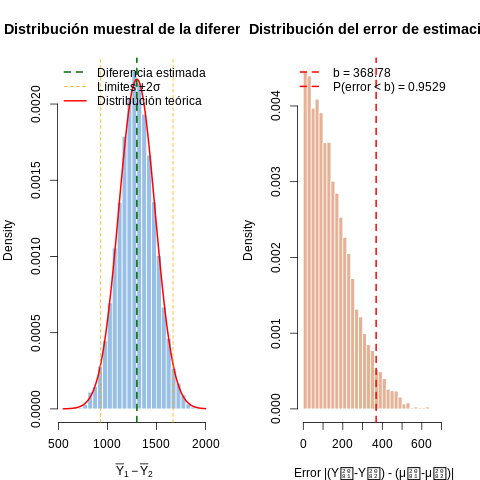

In [ ]:

# ============================================
# @title **B. EJEMPLO 3: COMPARACIÓN DE DOS MEDIAS**
# ============================================
%%R
# Datos
n1 <- 100
n2 <- 100
y1_bar <- 26400
y2_bar <- 25100
s1_2 <- 1440000  # varianza
s2_2 <- 1960000

# Estimación de la diferencia
diferencia <- y1_bar - y2_bar

# Error estándar estimado
se <- sqrt(s1_2 / n1 + s2_2 / n2)

# Límite de 2 desviaciones estándar
b <- 2 * se

cat("=== COMPARACIÓN DE DOS MEDIAS ===\n")
cat("Diferencia estimada (μ₁ - μ₂):", round(diferencia, 2), "millas\n")
cat("Error estándar estimado:", round(se, 2), "millas\n")
cat("Límite de 2σ:", round(b, 2), "millas\n")
cat("IC aproximado del 95%: [", round(diferencia - b, 2), ",",
    round(diferencia + b, 2), "] millas\n")

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN DE LA DIFERENCIA
# ============================================

set.seed(123)
n_sim <- 10000
mu1_verdadero <- 26400
mu2_verdadero <- 25100
sigma1 <- sqrt(s1_2)
sigma2 <- sqrt(s2_2)

# Simulación de diferencias muestrales
diferencias_sim <- replicate(n_sim, {
  y1 <- mean(rnorm(n1, mu1_verdadero, sigma1))
  y2 <- mean(rnorm(n2, mu2_verdadero, sigma2))
  y1 - y2
})

# Visualización
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Histograma de la distribución muestral de la diferencia
hist(diferencias_sim, breaks = 40, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Distribución muestral de la diferencia",
     xlab = expression(bar(Y)[1] - bar(Y)[2]))

# Curva normal teórica
x_vals <- seq(min(diferencias_sim), max(diferencias_sim), length.out = 500)
curve(dnorm(x, diferencia, se), add = TRUE, col = "red", lwd = 2)

# Límites de error
abline(v = diferencia, col = "darkgreen", lwd = 2, lty = 2)
abline(v = diferencia + b, col = "orange", lty = 2)
abline(v = diferencia - b, col = "orange", lty = 2)

legend("topright",
       legend = c("Diferencia estimada", "Límites ±2σ", "Distribución teórica"),
       col = c("darkgreen", "orange", "red"),
       lty = c(2, 2, 1), lwd = c(2, 1, 2), bty = "n")

# Gráfico de error de estimación
errores <- abs(diferencias_sim - diferencia)
hist(errores, breaks = 40, prob = TRUE,
     col = rgb(0.8, 0.4, 0.2, 0.5), border = "white",
     main = "Distribución del error de estimación",
     xlab = "Error |(Y₁-Y₂) - (μ₁-μ₂)|")
abline(v = b, col = "red", lwd = 2, lty = 2)

prob_menor_b <- mean(errores < b)
legend("topright",
       legend = c(paste("b =", round(b, 2)),
                  paste("P(error < b) =", round(prob_menor_b, 4))),
       col = "red", lty = 2, lwd = 2, bty = "n")




=== COMPARACIÓN DE DOS MEDIAS ===
Diferencia estimada (μ₁ - μ₂): 1300.00 millas
Error estándar estimado: 184.39 millas
Límite de 2σ: 368.78 millas
IC aproximado del 95%: [931.22, 1668.78] millas


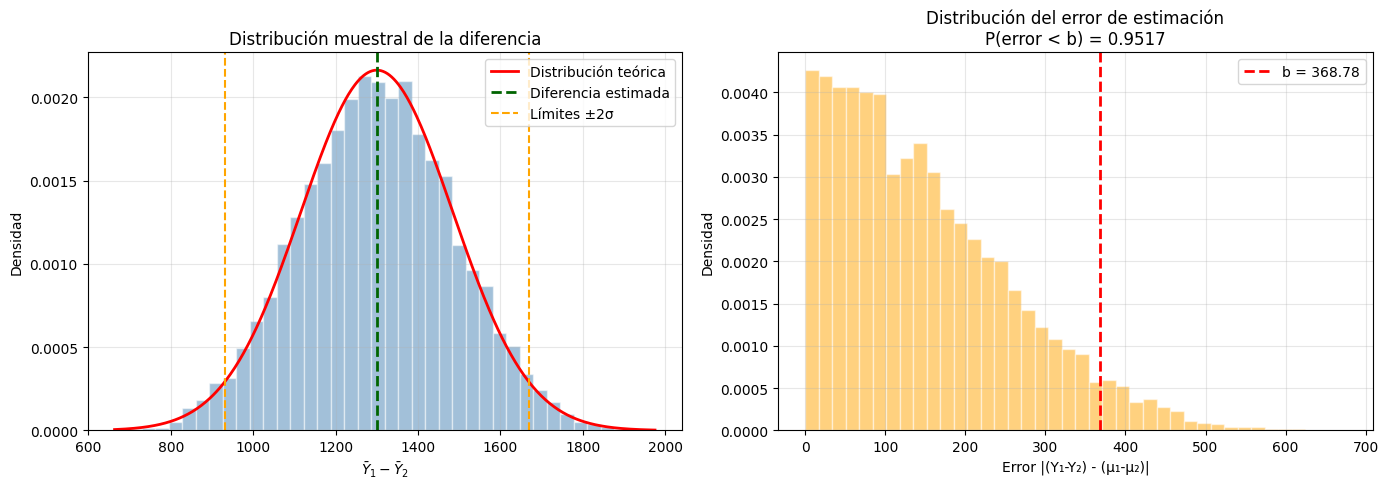

In [ ]:

# ============================================
# @title **C.  EJEMPLO 3: COMPARACIÓN DE DOS MEDIAS**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Datos
n1 = 100
n2 = 100
y1_bar = 26400
y2_bar = 25100
s1_2 = 1440000  # varianza
s2_2 = 1960000

# Estimación de la diferencia
diferencia = y1_bar - y2_bar

# Error estándar estimado
se = np.sqrt(s1_2 / n1 + s2_2 / n2)

# Límite de 2 desviaciones estándar
b = 2 * se

print("=== COMPARACIÓN DE DOS MEDIAS ===")
print(f"Diferencia estimada (μ₁ - μ₂): {diferencia:.2f} millas")
print(f"Error estándar estimado: {se:.2f} millas")
print(f"Límite de 2σ: {b:.2f} millas")
print(f"IC aproximado del 95%: [{diferencia - b:.2f}, {diferencia + b:.2f}] millas")

# ============================================
# SIMULACIÓN DE LA DISTRIBUCIÓN DE LA DIFERENCIA
# ============================================

np.random.seed(123)
n_sim = 10000
mu1_verdadero = 26400
mu2_verdadero = 25100
sigma1 = np.sqrt(s1_2)
sigma2 = np.sqrt(s2_2)

# Simulación de diferencias muestrales
diferencias_sim = []
for _ in range(n_sim):
    y1 = np.random.normal(mu1_verdadero, sigma1, n1).mean()
    y2 = np.random.normal(mu2_verdadero, sigma2, n2).mean()
    diferencias_sim.append(y1 - y2)

diferencias_sim = np.array(diferencias_sim)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución muestral de la diferencia
axes[0].hist(diferencias_sim, bins=40, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')

x_vals = np.linspace(diferencias_sim.min(), diferencias_sim.max(), 500)
y_vals = norm.pdf(x_vals, diferencia, se)
axes[0].plot(x_vals, y_vals, 'r-', lw=2, label='Distribución teórica')

axes[0].axvline(diferencia, color='darkgreen', linestyle='--',
                lw=2, label='Diferencia estimada')
axes[0].axvline(diferencia + b, color='orange', linestyle='--',
                label='Límites ±2σ')
axes[0].axvline(diferencia - b, color='orange', linestyle='--')
axes[0].set_xlabel(r'$\bar{Y}_1 - \bar{Y}_2$')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución muestral de la diferencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución del error de estimación
errores = np.abs(diferencias_sim - diferencia)
axes[1].hist(errores, bins=40, density=True, alpha=0.5,
             color='orange', edgecolor='white')
axes[1].axvline(b, color='red', linestyle='--', lw=2,
                label=f'b = {b:.2f}')

prob_menor_b = np.mean(errores < b)
axes[1].set_xlabel('Error |(Y₁-Y₂) - (μ₁-μ₂)|')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Distribución del error de estimación\n'
                  f'P(error < b) = {prob_menor_b:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T15"></a>
## **15. EJEMPLO 1: INTERVALO DE CONFIANZA PARA LA MEDIA**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== INTERVALO DE CONFIANZA PARA LA MEDIA ===
Tamaño de muestra (n): 64 
Media muestral (ȳ): 33 
Desviación estándar muestral (s): 16 
Nivel de confianza: 90 %
Valor crítico Z: 1.6449 
Error estándar: 2 
Margen de error: 3.2897 
IC 90%: [ 29.71 , 36.29 ]


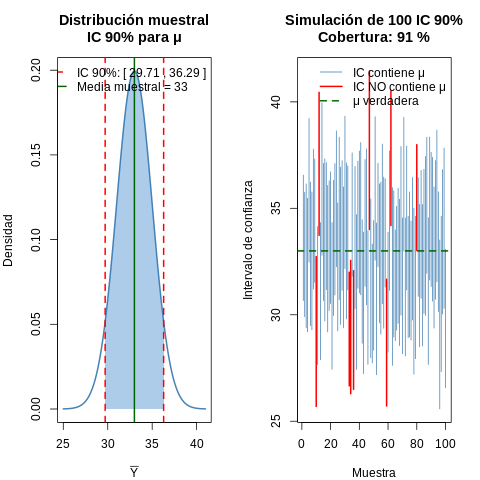

In [ ]:

# ============================================
# @title **B. EJEMPLO 1: INTERVALO DE CONFIANZA PARA LA MEDIA**
# ============================================
%%R
# Datos
n <- 64
y_bar <- 33
s2 <- 256
s <- sqrt(s2)
confianza <- 0.90

# Valor crítico Z
z_alpha2 <- qnorm((1 + confianza)/2)

# Error estándar
se <- s / sqrt(n)

# Intervalo de confianza
margen <- z_alpha2 * se
ic_inferior <- y_bar - margen
ic_superior <- y_bar + margen

cat("=== INTERVALO DE CONFIANZA PARA LA MEDIA ===\n")
cat("Tamaño de muestra (n):", n, "\n")
cat("Media muestral (ȳ):", y_bar, "\n")
cat("Desviación estándar muestral (s):", s, "\n")
cat("Nivel de confianza:", confianza * 100, "%\n")
cat("Valor crítico Z:", round(z_alpha2, 4), "\n")
cat("Error estándar:", round(se, 4), "\n")
cat("Margen de error:", round(margen, 4), "\n")
cat("IC 90%: [", round(ic_inferior, 2), ",", round(ic_superior, 2), "]\n")

# ============================================
# VISUALIZACIÓN DEL INTERVALO DE CONFIANZA
# ============================================

# Distribución muestral
x_vals <- seq(y_bar - 4*se, y_bar + 4*se, length.out = 500)
densidad <- dnorm(x_vals, mean = y_bar, sd = se)

# Región de confianza
x_fill <- seq(ic_inferior, ic_superior, length.out = 100)
y_fill <- dnorm(x_fill, mean = y_bar, sd = se)

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución muestral con IC
plot(x_vals, densidad, type = "l", lwd = 2, col = "steelblue",
     xlab = expression(bar(Y)), ylab = "Densidad",
     main = paste("Distribución muestral\nIC 90% para μ"))

polygon(c(x_fill, rev(x_fill)), c(y_fill, rep(0, length(x_fill))),
        col = rgb(0.2, 0.5, 0.8, 0.4), border = NA)
abline(v = c(ic_inferior, ic_superior), col = "red", lty = 2, lwd = 2)
abline(v = y_bar, col = "darkgreen", lwd = 2)

legend("topright",
       legend = c(paste("IC 90%: [", round(ic_inferior, 2), ",",
                        round(ic_superior, 2), "]"),
                  paste("Media muestral =", y_bar)),
       col = c("red", "darkgreen"), lty = c(2, 1), lwd = 2, bty = "n")

# Gráfico 2: Simulación de intervalos de confianza
set.seed(123)
n_sim <- 100
mu_verdadera <- 33
sigma_verdadera <- 16

ic_inferiores_sim <- numeric(n_sim)
ic_superiores_sim <- numeric(n_sim)
contiene_mu <- logical(n_sim)

for (i in 1:n_sim) {
  muestra <- rnorm(n, mu_verdadera, sigma_verdadera)
  y_bar_sim <- mean(muestra)
  s_sim <- sd(muestra)
  se_sim <- s_sim / sqrt(n)
  ic_inferiores_sim[i] <- y_bar_sim - z_alpha2 * se_sim
  ic_superiores_sim[i] <- y_bar_sim + z_alpha2 * se_sim
  contiene_mu[i] <- (ic_inferiores_sim[i] <= mu_verdadera &
                     ic_superiores_sim[i] >= mu_verdadera)
}

plot(1:n_sim, ic_inferiores_sim, type = "n",
     xlab = "Muestra", ylab = "Intervalo de confianza",
     ylim = range(c(ic_inferiores_sim, ic_superiores_sim)),
     main = paste("Simulación de", n_sim, "IC 90%\nCobertura:",
                  mean(contiene_mu) * 100, "%"))

for (i in 1:n_sim) {
  if (contiene_mu[i]) {
    segments(i, ic_inferiores_sim[i], i, ic_superiores_sim[i],
             col = "steelblue", lwd = 1)
  } else {
    segments(i, ic_inferiores_sim[i], i, ic_superiores_sim[i],
             col = "red", lwd = 2)
  }
}
abline(h = mu_verdadera, col = "darkgreen", lwd = 2, lty = 2)
legend("topright", legend = c("IC contiene μ", "IC NO contiene μ", "μ verdadera"),
       col = c("steelblue", "red", "darkgreen"),
       lty = c(1, 1, 2), lwd = c(1, 2, 2), bty = "n")




=== INTERVALO DE CONFIANZA PARA LA MEDIA ===
Tamaño de muestra (n): 64
Media muestral (ȳ): 33
Desviación estándar muestral (s): 16.0
Nivel de confianza: 90.0%
Valor crítico Z: 1.6449
Error estándar: 2.0000
Margen de error: 3.2897
IC 90%: [29.71, 36.29]


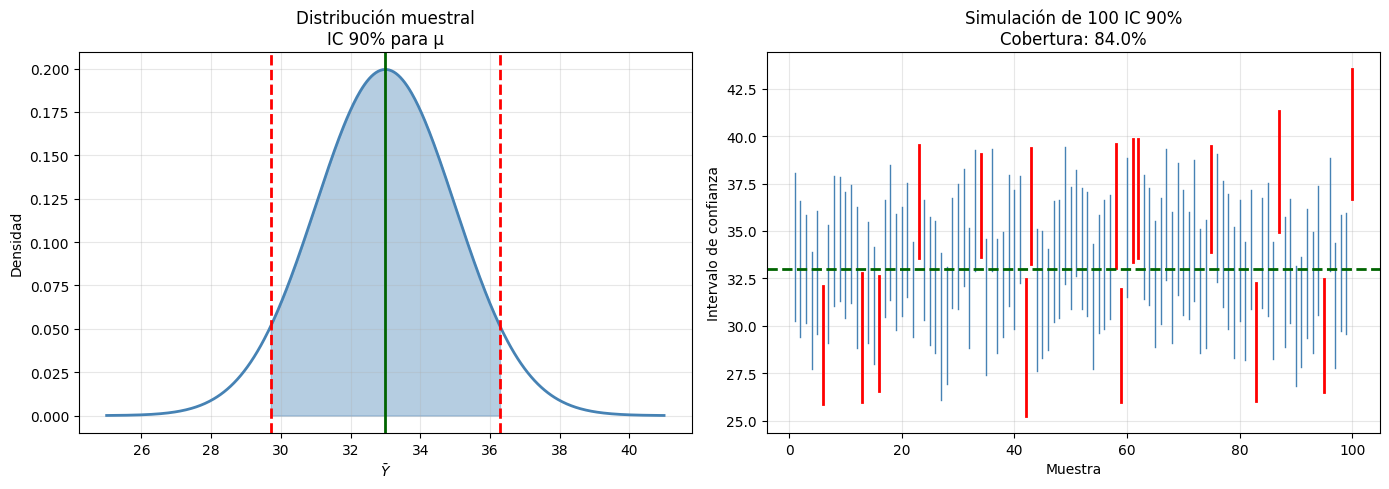

In [ ]:

# ============================================
# @title **C. EJEMPLO 1: INTERVALO DE CONFIANZA PARA LA MEDIA**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Datos
n = 64
y_bar = 33
s2 = 256
s = np.sqrt(s2)
confianza = 0.90

# Valor crítico Z
z_alpha2 = norm.ppf((1 + confianza)/2)

# Error estándar
se = s / np.sqrt(n)

# Intervalo de confianza
margen = z_alpha2 * se
ic_inferior = y_bar - margen
ic_superior = y_bar + margen

print("=== INTERVALO DE CONFIANZA PARA LA MEDIA ===")
print(f"Tamaño de muestra (n): {n}")
print(f"Media muestral (ȳ): {y_bar}")
print(f"Desviación estándar muestral (s): {s}")
print(f"Nivel de confianza: {confianza*100}%")
print(f"Valor crítico Z: {z_alpha2:.4f}")
print(f"Error estándar: {se:.4f}")
print(f"Margen de error: {margen:.4f}")
print(f"IC 90%: [{ic_inferior:.2f}, {ic_superior:.2f}]")

# ============================================
# VISUALIZACIÓN DEL INTERVALO DE CONFIANZA
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución muestral con IC
x_vals = np.linspace(y_bar - 4*se, y_bar + 4*se, 500)
densidad = norm.pdf(x_vals, y_bar, se)

axes[0].plot(x_vals, densidad, 'steelblue', lw=2)
x_fill = np.linspace(ic_inferior, ic_superior, 100)
y_fill = norm.pdf(x_fill, y_bar, se)
axes[0].fill_between(x_fill, y_fill, alpha=0.4, color='steelblue')
axes[0].axvline(ic_inferior, color='red', linestyle='--', lw=2)
axes[0].axvline(ic_superior, color='red', linestyle='--', lw=2)
axes[0].axvline(y_bar, color='darkgreen', lw=2)
axes[0].set_xlabel(r'$\bar{Y}$')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución muestral\nIC 90% para μ')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Simulación de intervalos de confianza
np.random.seed(123)
n_sim = 100
mu_verdadera = 33
sigma_verdadera = 16

ic_inferiores_sim = []
ic_superiores_sim = []
contiene_mu = []

for i in range(n_sim):
    muestra = np.random.normal(mu_verdadera, sigma_verdadera, n)
    y_bar_sim = np.mean(muestra)
    s_sim = np.std(muestra, ddof=1)
    se_sim = s_sim / np.sqrt(n)
    ic_inf = y_bar_sim - z_alpha2 * se_sim
    ic_sup = y_bar_sim + z_alpha2 * se_sim
    ic_inferiores_sim.append(ic_inf)
    ic_superiores_sim.append(ic_sup)
    contiene_mu.append(ic_inf <= mu_verdadera <= ic_sup)

ic_inferiores_sim = np.array(ic_inferiores_sim)
ic_superiores_sim = np.array(ic_superiores_sim)
contiene_mu = np.array(contiene_mu)

for i in range(n_sim):
    color = 'steelblue' if contiene_mu[i] else 'red'
    axes[1].plot([i+1, i+1], [ic_inferiores_sim[i], ic_superiores_sim[i]],
                 color=color, lw=1 if contiene_mu[i] else 2)

axes[1].axhline(mu_verdadera, color='darkgreen', lw=2, linestyle='--')
axes[1].set_xlabel('Muestra')
axes[1].set_ylabel('Intervalo de confianza')
axes[1].set_title(f'Simulación de {n_sim} IC 90%\nCobertura: {np.mean(contiene_mu)*100:.1f}%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




[⬆️ Volver al inicio](#inicio2)

<a name="T16"></a>
## **16. EJEMPLO 2: INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES ===
Marca A - n₁: 50 , fallas: 12 , p̂₁ = 0.24 
Marca B - n₂: 60 , fallas: 12 , p̂₂ = 0.2 
Diferencia estimada (p̂₁ - p̂₂): 0.04 
Nivel de confianza: 98 %
Valor crítico Z: 2.3263 
Error estándar: 0.0795 
Margen de error: 0.1849 
IC 98%: [ -0.1449 , 0.2249 ]

El intervalo contiene el cero, no hay evidencia de diferencia significativa.


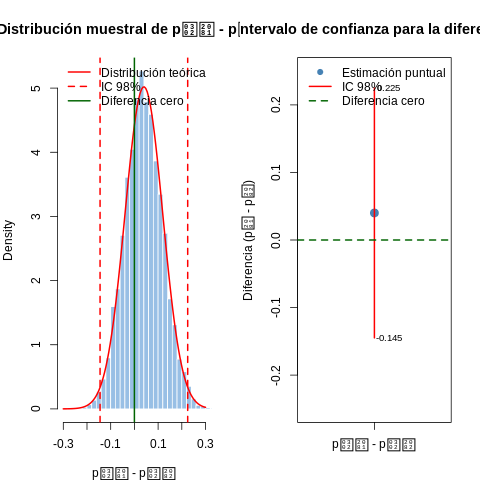

In [ ]:

# ============================================
# @title **B. EJEMPLO 2: INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES**
# ============================================
%%R
# Datos
n1 <- 50
x1 <- 12
n2 <- 60
x2 <- 12
confianza <- 0.98

# Proporciones muestrales
p1_hat <- x1 / n1
p2_hat <- x2 / n2
q1_hat <- 1 - p1_hat
q2_hat <- 1 - p2_hat
diferencia <- p1_hat - p2_hat

# Valor crítico Z
z_alpha2 <- qnorm((1 + confianza)/2)

# Error estándar
se <- sqrt(p1_hat * q1_hat / n1 + p2_hat * q2_hat / n2)

# Intervalo de confianza
margen <- z_alpha2 * se
ic_inferior <- diferencia - margen
ic_superior <- diferencia + margen

cat("=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES ===\n")
cat("Marca A - n₁:", n1, ", fallas:", x1, ", p̂₁ =", round(p1_hat, 4), "\n")
cat("Marca B - n₂:", n2, ", fallas:", x2, ", p̂₂ =", round(p2_hat, 4), "\n")
cat("Diferencia estimada (p̂₁ - p̂₂):", round(diferencia, 4), "\n")
cat("Nivel de confianza:", confianza * 100, "%\n")
cat("Valor crítico Z:", round(z_alpha2, 4), "\n")
cat("Error estándar:", round(se, 4), "\n")
cat("Margen de error:", round(margen, 4), "\n")
cat("IC 98%: [", round(ic_inferior, 4), ",", round(ic_superior, 4), "]\n")
cat("\nEl intervalo contiene el cero, no hay evidencia de diferencia significativa.\n")

# ============================================
# VISUALIZACIÓN
# ============================================

# Crear distribución aproximada de la diferencia
set.seed(123)
n_sim <- 10000
diferencias_sim <- replicate(n_sim, {
  p1_sim <- rbinom(1, n1, p1_hat) / n1
  p2_sim <- rbinom(1, n2, p2_hat) / n2
  p1_sim - p2_sim
})

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Histograma de la diferencia
hist(diferencias_sim, breaks = 40, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = "Distribución muestral de p̂₁ - p̂₂",
     xlab = "p̂₁ - p̂₂", xlim = c(-0.3, 0.3))

# Curva normal teórica
x_vals <- seq(-0.3, 0.3, length.out = 500)
curve(dnorm(x, diferencia, se), add = TRUE, col = "red", lwd = 2)

# Intervalo de confianza
abline(v = ic_inferior, col = "red", lty = 2, lwd = 2)
abline(v = ic_superior, col = "red", lty = 2, lwd = 2)
abline(v = 0, col = "darkgreen", lwd = 2)

legend("topright",
       legend = c("Distribución teórica", "IC 98%", "Diferencia cero"),
       col = c("red", "red", "darkgreen"),
       lty = c(1, 2, 1), lwd = c(2, 2, 2), bty = "n")

# Gráfico de la diferencia con su IC
plot(1, diferencia, pch = 19, col = "steelblue", cex = 1.5,
     xlim = c(0.5, 1.5), ylim = c(-0.25, 0.25),
     xlab = "", ylab = "Diferencia (p₁ - p₂)",
     xaxt = "n", main = "Intervalo de confianza para la diferencia")
axis(1, at = 1, labels = "p̂₁ - p̂₂")

segments(1, ic_inferior, 1, ic_superior, col = "red", lwd = 2)
abline(h = 0, col = "darkgreen", lty = 2, lwd = 2)
text(1.1, ic_inferior, labels = round(ic_inferior, 3), cex = 0.8)
text(1.1, ic_superior, labels = round(ic_superior, 3), cex = 0.8)

legend("topright", legend = c("Estimación puntual", "IC 98%", "Diferencia cero"),
       col = c("steelblue", "red", "darkgreen"),
       pch = c(19, NA, NA), lty = c(NA, 1, 2), lwd = c(NA, 2, 2), bty = "n")



=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES ===
Marca A - n₁: 50, fallas: 12, p̂₁ = 0.2400
Marca B - n₂: 60, fallas: 12, p̂₂ = 0.2000
Diferencia estimada (p̂₁ - p̂₂): 0.0400
Nivel de confianza: 98.0%
Valor crítico Z: 2.3263
Error estándar: 0.0795
Margen de error: 0.1849
IC 98%: [-0.1449, 0.2249]

El intervalo contiene el cero, no hay evidencia de diferencia significativa.


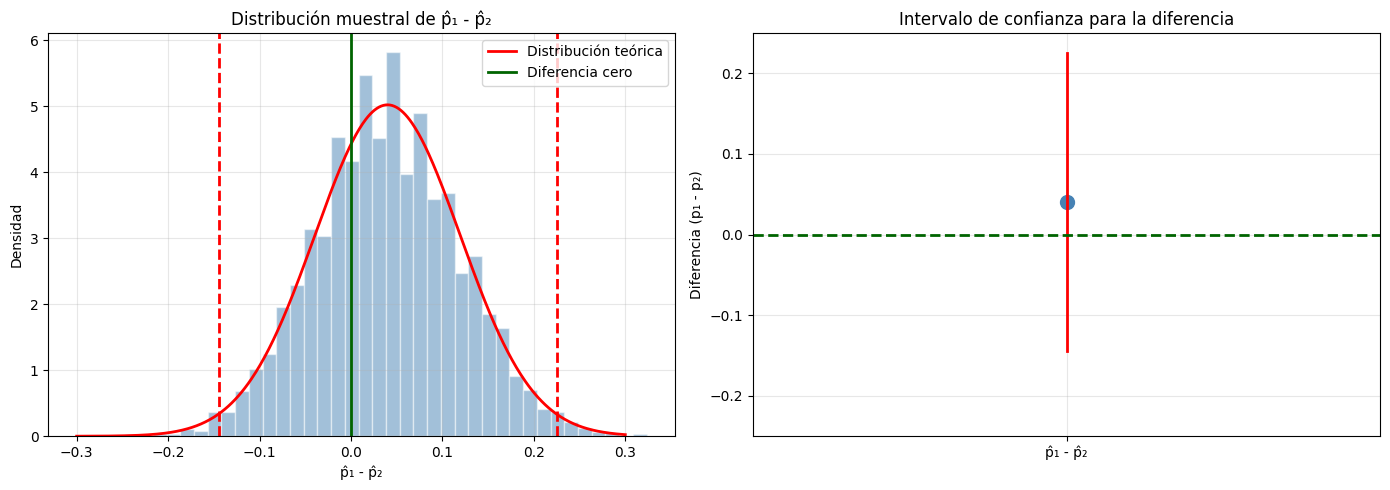

In [ ]:

# ============================================
# @title **C. EJEMPLO 2: INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

# Datos
n1 = 50
x1 = 12
n2 = 60
x2 = 12
confianza = 0.98

# Proporciones muestrales
p1_hat = x1 / n1
p2_hat = x2 / n2
q1_hat = 1 - p1_hat
q2_hat = 1 - p2_hat
diferencia = p1_hat - p2_hat

# Valor crítico Z
z_alpha2 = norm.ppf((1 + confianza)/2)

# Error estándar
se = np.sqrt(p1_hat * q1_hat / n1 + p2_hat * q2_hat / n2)

# Intervalo de confianza
margen = z_alpha2 * se
ic_inferior = diferencia - margen
ic_superior = diferencia + margen

print("=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE PROPORCIONES ===")
print(f"Marca A - n₁: {n1}, fallas: {x1}, p̂₁ = {p1_hat:.4f}")
print(f"Marca B - n₂: {n2}, fallas: {x2}, p̂₂ = {p2_hat:.4f}")
print(f"Diferencia estimada (p̂₁ - p̂₂): {diferencia:.4f}")
print(f"Nivel de confianza: {confianza*100}%")
print(f"Valor crítico Z: {z_alpha2:.4f}")
print(f"Error estándar: {se:.4f}")
print(f"Margen de error: {margen:.4f}")
print(f"IC 98%: [{ic_inferior:.4f}, {ic_superior:.4f}]")
print("\nEl intervalo contiene el cero, no hay evidencia de diferencia significativa.")

# ============================================
# VISUALIZACIÓN
# ============================================

np.random.seed(123)
n_sim = 10000
diferencias_sim = []
for _ in range(n_sim):
    p1_sim = np.random.binomial(n1, p1_hat, 1)[0] / n1
    p2_sim = np.random.binomial(n2, p2_hat, 1)[0] / n2
    diferencias_sim.append(p1_sim - p2_sim)
diferencias_sim = np.array(diferencias_sim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Histograma de la diferencia
axes[0].hist(diferencias_sim, bins=40, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')
x_vals = np.linspace(-0.3, 0.3, 500)
y_vals = norm.pdf(x_vals, diferencia, se)
axes[0].plot(x_vals, y_vals, 'r-', lw=2, label='Distribución teórica')
axes[0].axvline(ic_inferior, color='red', linestyle='--', lw=2)
axes[0].axvline(ic_superior, color='red', linestyle='--', lw=2)
axes[0].axvline(0, color='darkgreen', lw=2, label='Diferencia cero')
axes[0].set_xlabel("p̂₁ - p̂₂")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución muestral de p̂₁ - p̂₂")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Intervalo de confianza
axes[1].plot(1, diferencia, 'o', color='steelblue', markersize=10)
axes[1].plot([1, 1], [ic_inferior, ic_superior], 'r-', lw=2)
axes[1].axhline(0, color='darkgreen', linestyle='--', lw=2)
axes[1].set_xlim(0.5, 1.5)
axes[1].set_ylim(-0.25, 0.25)
axes[1].set_xticks([1])
axes[1].set_xticklabels(["p̂₁ - p̂₂"])
axes[1].set_ylabel("Diferencia (p₁ - p₂)")
axes[1].set_title("Intervalo de confianza para la diferencia")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T17"></a>
## **17. Cálculo del tamaño de muestra necesario**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:


# @title **B. Cálculo del tamaño de muestra necesario $$n <- (z^2 * p_{estimado} * (1 - p_{estimado})) / error_{deseado}^2$$**
%%R
p_estimado <- 0.6
error_deseado <- 0.04
confianza <- 0.90

z <- qnorm((1 + confianza)/2)
n <- (z^2 * p_estimado * (1 - p_estimado)) / error_deseado^2
cat("Tamaño de muestra necesario: n = ", ceiling(n))



Tamaño de muestra necesario: n =  406

In [ ]:
# @title **C. Cálculo del tamaño de muestra necesario $$n <- (z^2 * p_{estimado} * (1 - p_{estimado})) / error_{deseado}^2$$**

import numpy as np
from scipy.stats import norm

# Parámetros
p_estimado = 0.6
error_deseado = 0.04
confianza = 0.90

# Valor crítico Z
z = norm.ppf((1 + confianza) / 2)

# Cálculo del tamaño de muestra
n = (z**2 * p_estimado * (1 - p_estimado)) / error_deseado**2

print(f"Tamaño de muestra necesario: n = {np.ceil(n):.0f}")

Tamaño de muestra necesario: n = 406


[⬆️ Volver al inicio](#inicio2)

<a name="T18"></a>
## **18. EJEMPLO 3: INTERVALO DE CONFIANZA CON t DE STUDENT**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:

# ============================================
# @title **B. EJEMPLO 3: INTERVALO DE CONFIANZA CON t DE STUDENT**
# ============================================

# Datos
velocidades <- c(3005, 2995, 2925, 3005, 2935, 2937, 2965, 2905)
n <- length(velocidades)
y_bar <- mean(velocidades)
s <- sd(velocidades)
confianza <- 0.95

# Valor crítico t
t_alpha2 <- qt((1 + confianza)/2, df = n - 1)

# Error estándar
se <- s / sqrt(n)

# Intervalo de confianza
margen <- t_alpha2 * se
ic_inferior <- y_bar - margen
ic_superior <- y_bar + margen

cat("=== INTERVALO DE CONFIANZA CON t DE STUDENT ===\n")
cat("Datos:", velocidades, "\n")
cat("Tamaño de muestra (n):", n, "\n")
cat("Media muestral (ȳ):", round(y_bar, 2), "\n")
cat("Desviación estándar muestral (s):", round(s, 2), "\n")
cat("Nivel de confianza:", confianza * 100, "%\n")
cat("Valor crítico t:", round(t_alpha2, 4), "\n")
cat("Error estándar:", round(se, 2), "\n")
cat("Margen de error:", round(margen, 2), "\n")
cat("IC 95%: [", round(ic_inferior, 2), ",", round(ic_superior, 2), "]\n")

# ============================================
# VISUALIZACIÓN
# ============================================

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución t de Student
x_vals <- seq(-4, 4, length.out = 500)
densidad_t <- dt(x_vals, df = n - 1)
densidad_norm <- dnorm(x_vals)

plot(x_vals, densidad_t, type = "l", lwd = 2, col = "purple",
     xlab = "t", ylab = "Densidad",
     main = paste("Distribución t con", n-1, "grados de libertad"))
lines(x_vals, densidad_norm, col = "steelblue", lty = 2, lwd = 2)

# Región de confianza
x_fill <- seq(-t_alpha2, t_alpha2, length.out = 100)
y_fill <- dt(x_fill, df = n - 1)
polygon(c(x_fill, rev(x_fill)), c(y_fill, rep(0, length(x_fill))),
        col = rgb(0.6, 0.4, 0.8, 0.4), border = NA)

abline(v = c(-t_alpha2, t_alpha2), col = "red", lty = 2)

legend("topright",
       legend = c(paste("t(7)"), "Normal(0,1)", "Región de confianza 95%"),
       col = c("purple", "steelblue", rgb(0.6, 0.4, 0.8, 0.4)),
       lty = c(1, 2, NA), lwd = c(2, 2, NA),
       fill = c(NA, NA, rgb(0.6, 0.4, 0.8, 0.4)), bty = "n")

# Gráfico 2: Datos con intervalo de confianza
plot(1:n, velocidades, pch = 19, col = "steelblue", cex = 1.2,
     xlab = "Observación", ylab = "Velocidad (pies/seg)",
     main = "Datos de velocidades con IC 95%")
abline(h = y_bar, col = "darkgreen", lwd = 2)
abline(h = c(ic_inferior, ic_superior), col = "red", lty = 2, lwd = 2)
segments(1, ic_inferior, n, ic_inferior, col = "red", lty = 2)
segments(1, ic_superior, n, ic_superior, col = "red", lty = 2)

legend("topleft",
       legend = c(paste("Media =", round(y_bar, 1)),
                  paste("IC 95%: [", round(ic_inferior, 1), ",",
                        round(ic_superior, 1), "]")),
       col = c("darkgreen", "red"), lty = c(1, 2), lwd = 2, bty = "n")




=== INTERVALO DE CONFIANZA CON t DE STUDENT ===
Datos: [3005 2995 2925 3005 2935 2937 2965 2905]
Tamaño de muestra (n): 8
Media muestral (ȳ): 2959.00
Desviación estándar muestral (s): 39.09
Nivel de confianza: 95.0%
Valor crítico t: 2.3646
Error estándar: 13.82
Margen de error: 32.68
IC 95%: [2926.32, 2991.68]


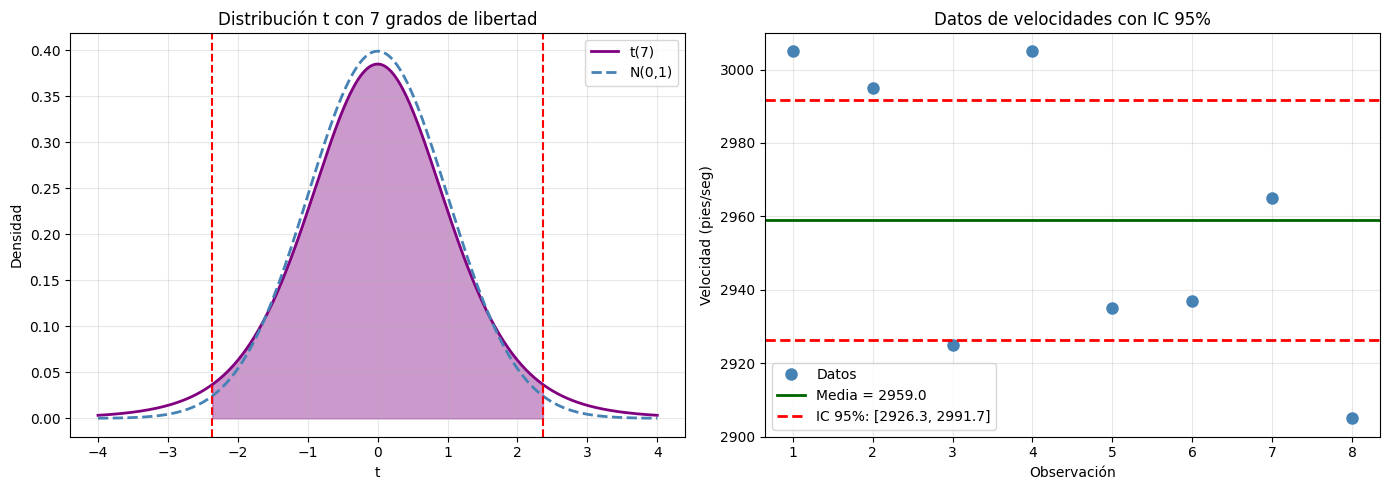

In [ ]:

# ============================================
# @title **C.EJEMPLO 3: INTERVALO DE CONFIANZA CON t DE STUDENT**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Datos
velocidades = np.array([3005, 2995, 2925, 3005, 2935, 2937, 2965, 2905])
n = len(velocidades)
y_bar = np.mean(velocidades)
s = np.std(velocidades, ddof=1)
confianza = 0.95

# Valor crítico t
t_alpha2 = t.ppf((1 + confianza)/2, df=n-1)

# Error estándar
se = s / np.sqrt(n)

# Intervalo de confianza
margen = t_alpha2 * se
ic_inferior = y_bar - margen
ic_superior = y_bar + margen

print("=== INTERVALO DE CONFIANZA CON t DE STUDENT ===")
print(f"Datos: {velocidades}")
print(f"Tamaño de muestra (n): {n}")
print(f"Media muestral (ȳ): {y_bar:.2f}")
print(f"Desviación estándar muestral (s): {s:.2f}")
print(f"Nivel de confianza: {confianza*100}%")
print(f"Valor crítico t: {t_alpha2:.4f}")
print(f"Error estándar: {se:.2f}")
print(f"Margen de error: {margen:.2f}")
print(f"IC 95%: [{ic_inferior:.2f}, {ic_superior:.2f}]")

# ============================================
# VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución t de Student
x_vals = np.linspace(-4, 4, 500)
densidad_t = t.pdf(x_vals, df=n-1)
densidad_norm = norm.pdf(x_vals)

axes[0].plot(x_vals, densidad_t, 'purple', lw=2, label=f't({n-1})')
axes[0].plot(x_vals, densidad_norm, 'steelblue', lw=2,
             linestyle='--', label='N(0,1)')

x_fill = np.linspace(-t_alpha2, t_alpha2, 100)
y_fill = t.pdf(x_fill, df=n-1)
axes[0].fill_between(x_fill, y_fill, alpha=0.4, color='purple')
axes[0].axvline(-t_alpha2, color='red', linestyle='--')
axes[0].axvline(t_alpha2, color='red', linestyle='--')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución t con {n-1} grados de libertad')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Datos con intervalo de confianza
axes[1].plot(range(1, n+1), velocidades, 'o', color='steelblue',
             markersize=8, label='Datos')
axes[1].axhline(y_bar, color='darkgreen', lw=2,
                label=f'Media = {y_bar:.1f}')
axes[1].axhline(ic_inferior, color='red', linestyle='--', lw=2,
                label=f'IC 95%: [{ic_inferior:.1f}, {ic_superior:.1f}]')
axes[1].axhline(ic_superior, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Observación')
axes[1].set_ylabel('Velocidad (pies/seg)')
axes[1].set_title('Datos de velocidades con IC 95%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




[⬆️ Volver al inicio](#inicio2)

<a name="T19"></a>
## **19. EJEMPLO 4: INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS ===
Procedimiento estándar:
  n₁ = 9 , media = 35.22 , s₁ = 4.94 
Procedimiento nuevo:
  n₂ = 9 , media = 31.56 , s₂ = 4.48 
Diferencia estimada (μ₁ - μ₂): 3.67 
Varianza combinada (sₚ²): 22.24 
Desviación combinada (sₚ): 4.72 
Valor crítico t: 2.1199 
Error estándar: 2.223 
Margen de error: 4.71 
IC 95%: [ -1.05 , 8.38 ]

El intervalo contiene el cero, no hay evidencia de diferencia significativa.


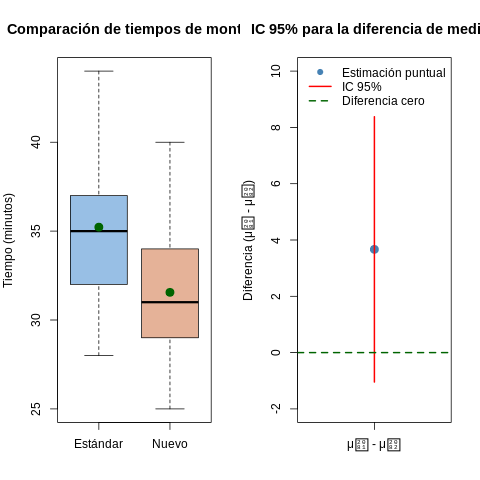

In [ ]:

# ============================================
# @title **B. EJEMPLO 4: INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS**
# ============================================
%%R
# Datos
estandar <- c(32, 37, 35, 28, 41, 44, 35, 31, 34)
nuevo <- c(35, 31, 29, 25, 34, 40, 27, 32, 31)

n1 <- length(estandar)
n2 <- length(nuevo)
y1_bar <- mean(estandar)
y2_bar <- mean(nuevo)
s1 <- sd(estandar)
s2 <- sd(nuevo)
confianza <- 0.95

# Varianza combinada
sp2 <- ((n1 - 1) * s1^2 + (n2 - 1) * s2^2) / (n1 + n2 - 2)
sp <- sqrt(sp2)

# Valor crítico t
t_alpha2 <- qt((1 + confianza)/2, df = n1 + n2 - 2)

# Diferencia de medias
diferencia <- y1_bar - y2_bar

# Error estándar
se <- sp * sqrt(1/n1 + 1/n2)

# Intervalo de confianza
margen <- t_alpha2 * se
ic_inferior <- diferencia - margen
ic_superior <- diferencia + margen

cat("=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS ===\n")
cat("Procedimiento estándar:\n")
cat("  n₁ =", n1, ", media =", round(y1_bar, 2), ", s₁ =", round(s1, 2), "\n")
cat("Procedimiento nuevo:\n")
cat("  n₂ =", n2, ", media =", round(y2_bar, 2), ", s₂ =", round(s2, 2), "\n")
cat("Diferencia estimada (μ₁ - μ₂):", round(diferencia, 2), "\n")
cat("Varianza combinada (sₚ²):", round(sp2, 2), "\n")
cat("Desviación combinada (sₚ):", round(sp, 2), "\n")
cat("Valor crítico t:", round(t_alpha2, 4), "\n")
cat("Error estándar:", round(se, 3), "\n")
cat("Margen de error:", round(margen, 2), "\n")
cat("IC 95%: [", round(ic_inferior, 2), ",", round(ic_superior, 2), "]\n")
cat("\nEl intervalo contiene el cero, no hay evidencia de diferencia significativa.\n")

# ============================================
# VISUALIZACIÓN
# ============================================

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Boxplots comparativos
boxplot(estandar, nuevo, names = c("Estándar", "Nuevo"),
        col = c(rgb(0.2, 0.5, 0.8, 0.5), rgb(0.8, 0.4, 0.2, 0.5)),
        main = "Comparación de tiempos de montaje",
        ylab = "Tiempo (minutos)")
points(1, y1_bar, col = "darkgreen", pch = 19, cex = 1.5)
points(2, y2_bar, col = "darkgreen", pch = 19, cex = 1.5)

# Gráfico 2: Intervalo de confianza para la diferencia
plot(1, diferencia, pch = 19, col = "steelblue", cex = 1.5,
     xlim = c(0.5, 1.5), ylim = c(-2, 10),
     xlab = "", ylab = "Diferencia (μ₁ - μ₂)",
     xaxt = "n", main = "IC 95% para la diferencia de medias")
axis(1, at = 1, labels = "μ₁ - μ₂")

segments(1, ic_inferior, 1, ic_superior, col = "red", lwd = 2)
abline(h = 0, col = "darkgreen", lty = 2, lwd = 2)

legend("topright",
       legend = c("Estimación puntual", "IC 95%", "Diferencia cero"),
       col = c("steelblue", "red", "darkgreen"),
       pch = c(19, NA, NA), lty = c(NA, 1, 2), lwd = c(NA, 2, 2), bty = "n")




=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS ===
Procedimiento estándar:
  n₁ = 9, media = 35.22, s₁ = 4.94
Procedimiento nuevo:
  n₂ = 9, media = 31.56, s₂ = 4.48
Diferencia estimada (μ₁ - μ₂): 3.67
Varianza combinada (sₚ²): 22.24
Desviación combinada (sₚ): 4.72
Valor crítico t: 2.1199
Error estándar: 2.223
Margen de error: 4.71
IC 95%: [-1.05, 8.38]

El intervalo contiene el cero, no hay evidencia de diferencia significativa.


/tmp/ipykernel_1420/4100508047.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=['Estándar', 'Nuevo'],


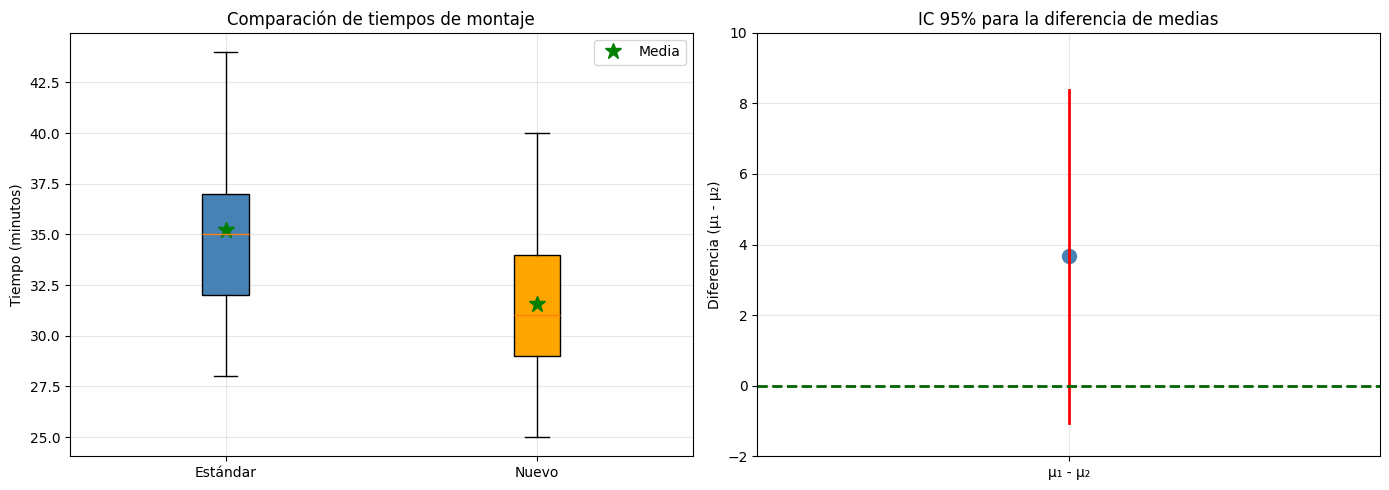

In [ ]:

# ============================================
# @title **C. EJEMPLO 4: INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Datos
estandar = np.array([32, 37, 35, 28, 41, 44, 35, 31, 34])
nuevo = np.array([35, 31, 29, 25, 34, 40, 27, 32, 31])

n1 = len(estandar)
n2 = len(nuevo)
y1_bar = np.mean(estandar)
y2_bar = np.mean(nuevo)
s1 = np.std(estandar, ddof=1)
s2 = np.std(nuevo, ddof=1)
confianza = 0.95

# Varianza combinada
sp2 = ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
sp = np.sqrt(sp2)

# Valor crítico t
t_alpha2 = t.ppf((1 + confianza)/2, df=n1 + n2 - 2)

# Diferencia de medias
diferencia = y1_bar - y2_bar

# Error estándar
se = sp * np.sqrt(1/n1 + 1/n2)

# Intervalo de confianza
margen = t_alpha2 * se
ic_inferior = diferencia - margen
ic_superior = diferencia + margen

print("=== INTERVALO DE CONFIANZA PARA DIFERENCIA DE MEDIAS ===")
print("Procedimiento estándar:")
print(f"  n₁ = {n1}, media = {y1_bar:.2f}, s₁ = {s1:.2f}")
print("Procedimiento nuevo:")
print(f"  n₂ = {n2}, media = {y2_bar:.2f}, s₂ = {s2:.2f}")
print(f"Diferencia estimada (μ₁ - μ₂): {diferencia:.2f}")
print(f"Varianza combinada (sₚ²): {sp2:.2f}")
print(f"Desviación combinada (sₚ): {sp:.2f}")
print(f"Valor crítico t: {t_alpha2:.4f}")
print(f"Error estándar: {se:.3f}")
print(f"Margen de error: {margen:.2f}")
print(f"IC 95%: [{ic_inferior:.2f}, {ic_superior:.2f}]")
print("\nEl intervalo contiene el cero, no hay evidencia de diferencia significativa.")

# ============================================
# VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Boxplots comparativos
data_to_plot = [estandar, nuevo]
bp = axes[0].boxplot(data_to_plot, labels=['Estándar', 'Nuevo'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('orange')
axes[0].plot(1, y1_bar, 'g*', markersize=12, label='Media')
axes[0].plot(2, y2_bar, 'g*', markersize=12)
axes[0].set_ylabel('Tiempo (minutos)')
axes[0].set_title('Comparación de tiempos de montaje')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Intervalo de confianza para la diferencia
axes[1].plot(1, diferencia, 'o', color='steelblue', markersize=10)
axes[1].plot([1, 1], [ic_inferior, ic_superior], 'r-', lw=2)
axes[1].axhline(0, color='darkgreen', linestyle='--', lw=2)
axes[1].set_xlim(0.5, 1.5)
axes[1].set_ylim(-2, 10)
axes[1].set_xticks([1])
axes[1].set_xticklabels(['μ₁ - μ₂'])
axes[1].set_ylabel('Diferencia (μ₁ - μ₂)')
axes[1].set_title('IC 95% para la diferencia de medias')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio2)

<a name="T20"></a>
## **20. EJEMPLOS 5 Y 6: INTERVALOS DE CONFIANZA PARA LA VARIANZA**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== EJEMPLO 5: EQUIPO DE MEDICIÓN ===
Datos: 4.1 5.2 10.2 
n = 3 , s² = 10.57 
IC 90% para σ²: [ 3.53 , 206.07 ]

=== EJEMPLO 6: RENDIMIENTO DE TRIGO ===
n = 20 , s² = 64 
IC 95% para σ²: [ 37.01 , 136.53 ]
IC 95% para σ: [ 6.08 , 11.68 ]


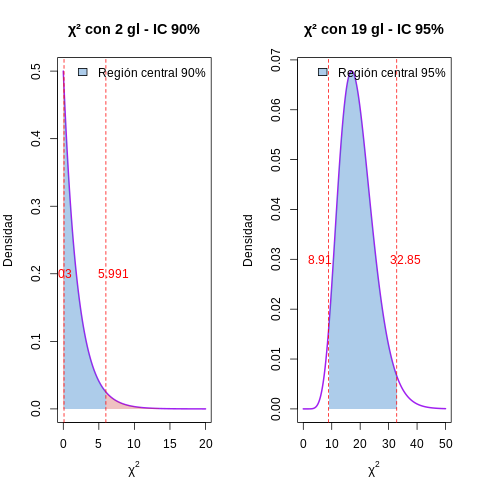

In [ ]:

# ============================================
# @title **B. EJEMPLOS 5 Y 6: INTERVALOS DE CONFIANZA PARA LA VARIANZA**
# ============================================
%%R
# Ejemplo 5: Datos de 3 mediciones
datos5 <- c(4.1, 5.2, 10.2)
n5 <- length(datos5)
s2_5 <- var(datos5)
confianza5 <- 0.90
alpha5 <- 1 - confianza5

chi2_inf5 <- qchisq(alpha5/2, df = n5 - 1)
chi2_sup5 <- qchisq(1 - alpha5/2, df = n5 - 1)

ic_inf5 <- (n5 - 1) * s2_5 / chi2_sup5
ic_sup5 <- (n5 - 1) * s2_5 / chi2_inf5

cat("=== EJEMPLO 5: EQUIPO DE MEDICIÓN ===\n")
cat("Datos:", datos5, "\n")
cat("n =", n5, ", s² =", round(s2_5, 2), "\n")
cat("IC 90% para σ²: [", round(ic_inf5, 2), ",", round(ic_sup5, 2), "]\n\n")

# Ejemplo 6: Datos de 20 parcelas
n6 <- 20
s2_6 <- 64
confianza6 <- 0.95
alpha6 <- 1 - confianza6

chi2_inf6 <- qchisq(alpha6/2, df = n6 - 1)
chi2_sup6 <- qchisq(1 - alpha6/2, df = n6 - 1)

ic_inf6 <- (n6 - 1) * s2_6 / chi2_sup6
ic_sup6 <- (n6 - 1) * s2_6 / chi2_inf6

cat("=== EJEMPLO 6: RENDIMIENTO DE TRIGO ===\n")
cat("n =", n6, ", s² =", s2_6, "\n")
cat("IC 95% para σ²: [", round(ic_inf6, 2), ",", round(ic_sup6, 2), "]\n")
cat("IC 95% para σ: [", round(sqrt(ic_inf6), 2), ",", round(sqrt(ic_sup6), 2), "]\n")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN CHI-CUADRADA
# ============================================

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución χ² con 2 grados de libertad (Ejemplo 5)
gl5 <- n5 - 1
x_vals5 <- seq(0, 20, length.out = 500)
densidad5 <- dchisq(x_vals5, df = gl5)

plot(x_vals5, densidad5, type = "l", lwd = 2, col = "purple",
     xlab = expression(chi^2), ylab = "Densidad",
     main = paste("χ² con", gl5, "gl - IC 90%"))

# Regiones críticas
x_fill_inf5 <- seq(0, chi2_inf5, length.out = 100)
y_fill_inf5 <- dchisq(x_fill_inf5, df = gl5)
x_fill_sup5 <- seq(chi2_sup5, max(x_vals5), length.out = 100)
y_fill_sup5 <- dchisq(x_fill_sup5, df = gl5)

polygon(c(x_fill_inf5, rev(x_fill_inf5)),
        c(y_fill_inf5, rep(0, length(x_fill_inf5))),
        col = rgb(0.8, 0.2, 0.2, 0.3), border = NA)
polygon(c(x_fill_sup5, rev(x_fill_sup5)),
        c(y_fill_sup5, rep(0, length(x_fill_sup5))),
        col = rgb(0.8, 0.2, 0.2, 0.3), border = NA)

x_fill_central5 <- seq(chi2_inf5, chi2_sup5, length.out = 100)
y_fill_central5 <- dchisq(x_fill_central5, df = gl5)
polygon(c(x_fill_central5, rev(x_fill_central5)),
        c(y_fill_central5, rep(0, length(x_fill_central5))),
        col = rgb(0.2, 0.5, 0.8, 0.4), border = NA)

abline(v = c(chi2_inf5, chi2_sup5), col = "red", lty = 2)
text(chi2_inf5 - 1, 0.2, labels = round(chi2_inf5, 3), col = "red")
text(chi2_sup5 + 1, 0.2, labels = round(chi2_sup5, 3), col = "red")

legend("topright", legend = "Región central 90%",
       fill = rgb(0.2, 0.5, 0.8, 0.4), bty = "n")

# Gráfico 2: Distribución χ² con 19 grados de libertad (Ejemplo 6)
gl6 <- n6 - 1
x_vals6 <- seq(0, 50, length.out = 500)
densidad6 <- dchisq(x_vals6, df = gl6)

plot(x_vals6, densidad6, type = "l", lwd = 2, col = "purple",
     xlab = expression(chi^2), ylab = "Densidad",
     main = paste("χ² con", gl6, "gl - IC 95%"))

x_fill_central6 <- seq(chi2_inf6, chi2_sup6, length.out = 100)
y_fill_central6 <- dchisq(x_fill_central6, df = gl6)
polygon(c(x_fill_central6, rev(x_fill_central6)),
        c(y_fill_central6, rep(0, length(x_fill_central6))),
        col = rgb(0.2, 0.5, 0.8, 0.4), border = NA)

abline(v = c(chi2_inf6, chi2_sup6), col = "red", lty = 2)
text(chi2_inf6 - 3, 0.03, labels = round(chi2_inf6, 2), col = "red")
text(chi2_sup6 + 3, 0.03, labels = round(chi2_sup6, 2), col = "red")

legend("topright", legend = "Región central 95%",
       fill = rgb(0.2, 0.5, 0.8, 0.4), bty = "n")



=== EJEMPLO 5: EQUIPO DE MEDICIÓN ===
Datos: [ 4.1  5.2 10.2]
n = 3, s² = 10.57
IC 90% para σ²: [3.53, 206.07]

=== EJEMPLO 6: RENDIMIENTO DE TRIGO ===
n = 20, s² = 64
IC 95% para σ²: [37.01, 136.53]
IC 95% para σ: [6.08, 11.68]


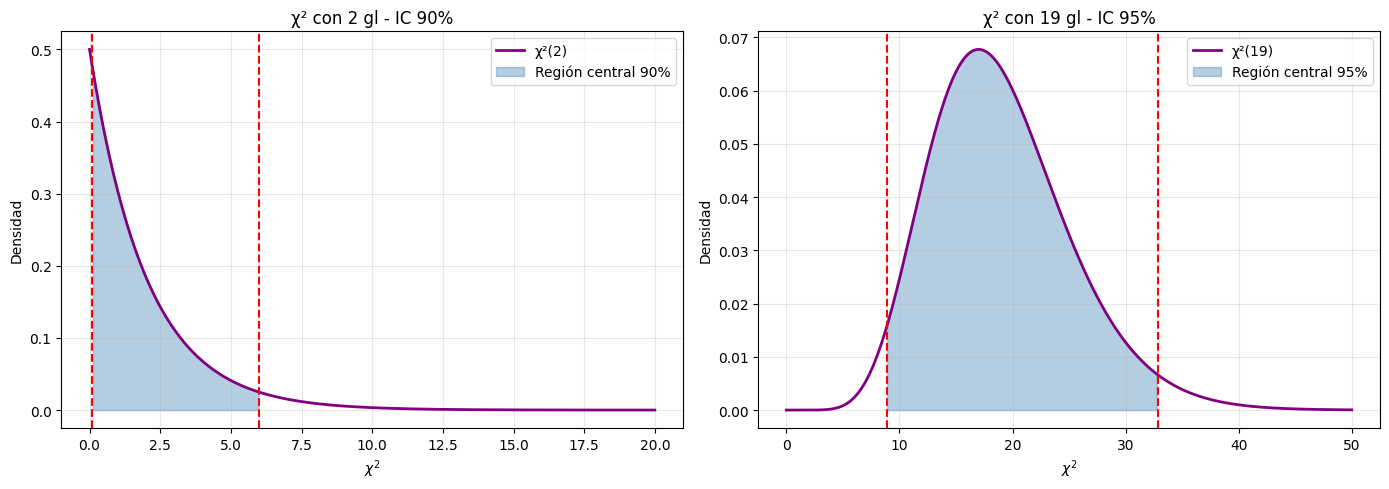

In [ ]:

# ============================================
# @title **C. EJEMPLOS 5 Y 6: INTERVALOS DE CONFIANZA PARA LA VARIANZA**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Ejemplo 5: Datos de 3 mediciones
datos5 = np.array([4.1, 5.2, 10.2])
n5 = len(datos5)
s2_5 = np.var(datos5, ddof=1)
confianza5 = 0.90
alpha5 = 1 - confianza5

chi2_inf5 = chi2.ppf(alpha5/2, df=n5-1)
chi2_sup5 = chi2.ppf(1 - alpha5/2, df=n5-1)

ic_inf5 = (n5 - 1) * s2_5 / chi2_sup5
ic_sup5 = (n5 - 1) * s2_5 / chi2_inf5

print("=== EJEMPLO 5: EQUIPO DE MEDICIÓN ===")
print(f"Datos: {datos5}")
print(f"n = {n5}, s² = {s2_5:.2f}")
print(f"IC 90% para σ²: [{ic_inf5:.2f}, {ic_sup5:.2f}]")

# Ejemplo 6: Datos de 20 parcelas
n6 = 20
s2_6 = 64
confianza6 = 0.95
alpha6 = 1 - confianza6

chi2_inf6 = chi2.ppf(alpha6/2, df=n6-1)
chi2_sup6 = chi2.ppf(1 - alpha6/2, df=n6-1)

ic_inf6 = (n6 - 1) * s2_6 / chi2_sup6
ic_sup6 = (n6 - 1) * s2_6 / chi2_inf6

print("\n=== EJEMPLO 6: RENDIMIENTO DE TRIGO ===")
print(f"n = {n6}, s² = {s2_6}")
print(f"IC 95% para σ²: [{ic_inf6:.2f}, {ic_sup6:.2f}]")
print(f"IC 95% para σ: [{np.sqrt(ic_inf6):.2f}, {np.sqrt(ic_sup6):.2f}]")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN CHI-CUADRADA
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución χ² con 2 grados de libertad (Ejemplo 5)
gl5 = n5 - 1
x_vals5 = np.linspace(0, 20, 500)
densidad5 = chi2.pdf(x_vals5, df=gl5)

axes[0].plot(x_vals5, densidad5, 'purple', lw=2, label=f'χ²({gl5})')
axes[0].fill_between(x_vals5[(x_vals5 >= chi2_inf5) & (x_vals5 <= chi2_sup5)],
                      densidad5[(x_vals5 >= chi2_inf5) & (x_vals5 <= chi2_sup5)],
                      alpha=0.4, color='steelblue', label='Región central 90%')
axes[0].axvline(chi2_inf5, color='red', linestyle='--')
axes[0].axvline(chi2_sup5, color='red', linestyle='--')
axes[0].set_xlabel(r'$\chi^2$')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'χ² con {gl5} gl - IC 90%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución χ² con 19 grados de libertad (Ejemplo 6)
gl6 = n6 - 1
x_vals6 = np.linspace(0, 50, 500)
densidad6 = chi2.pdf(x_vals6, df=gl6)

axes[1].plot(x_vals6, densidad6, 'purple', lw=2, label=f'χ²({gl6})')
axes[1].fill_between(x_vals6[(x_vals6 >= chi2_inf6) & (x_vals6 <= chi2_sup6)],
                      densidad6[(x_vals6 >= chi2_inf6) & (x_vals6 <= chi2_sup6)],
                      alpha=0.4, color='steelblue', label='Región central 95%')
axes[1].axvline(chi2_inf6, color='red', linestyle='--')
axes[1].axvline(chi2_sup6, color='red', linestyle='--')
axes[1].set_xlabel(r'$\chi^2$')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'χ² con {gl6} gl - IC 95%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio2)

<a name="T21"></a>
## **21. EJEMPLO 1: EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME ===
n = 10 , θ verdadero = 10 
Varianza de θ̂₁ (2Ȳ): 3.3051 
Varianza de θ̂₂ ((n+1)/n * Y₍ₙ₎): 0.8065 
Eficiencia relativa (simulada): 0.244 
Eficiencia relativa (teórica): 0.25 



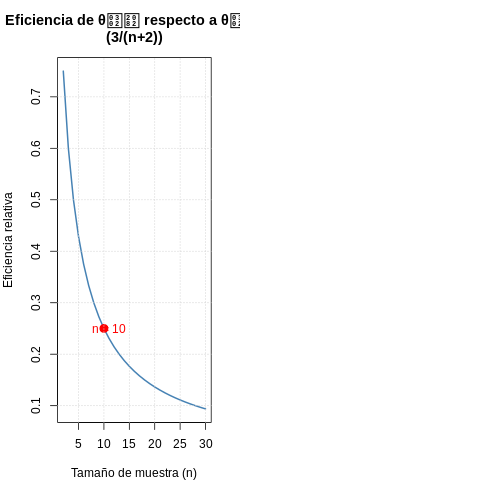

In [ ]:

# ============================================
# @title **B. EJEMPLO 1: EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME**
# ============================================
%%R
# Parámetros
theta_verdadero <- 10
n <- 10
n_sim <- 10000

# Simulación para comparar eficiencia
set.seed(123)

theta1_sim <- numeric(n_sim)
theta2_sim <- numeric(n_sim)

for (i in 1:n_sim) {
  muestra <- runif(n, 0, theta_verdadero)
  theta1_sim[i] <- 2 * mean(muestra)
  theta2_sim[i] <- ((n + 1) / n) * max(muestra)
}

# Varianzas muestrales
var_theta1 <- var(theta1_sim)
var_theta2 <- var(theta2_sim)
eficiencia <- var_theta2 / var_theta1
eficiencia_teorica <- 3 / (n + 2)

cat("=== EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME ===\n")
cat("n =", n, ", θ verdadero =", theta_verdadero, "\n")
cat("Varianza de θ̂₁ (2Ȳ):", round(var_theta1, 4), "\n")
cat("Varianza de θ̂₂ ((n+1)/n * Y₍ₙ₎):", round(var_theta2, 4), "\n")
cat("Eficiencia relativa (simulada):", round(eficiencia, 4), "\n")
cat("Eficiencia relativa (teórica):", round(eficiencia_teorica, 4), "\n\n")

# ============================================
# VISUALIZACIÓN DE LAS DISTRIBUCIONES
# ============================================

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Histogramas de los estimadores
hist(theta1_sim, breaks = 50, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white",
     main = expression("Distribución de " * hat(theta)[1] * " = 2Ȳ"),
     xlab = expression(hat(theta)[1]), xlim = c(5, 15))
abline(v = theta_verdadero, col = "red", lwd = 2, lty = 2)
legend("topright", legend = paste("θ =", theta_verdadero),
       col = "red", lty = 2, lwd = 2, bty = "n")

hist(theta2_sim, breaks = 50, prob = TRUE,
     col = rgb(0.8, 0.4, 0.2, 0.5), border = "white",
     main = expression("Distribución de " * hat(theta)[2] * " = (n+1)/n * Y₍ₙ₎"),
     xlab = expression(hat(theta)[2]), xlim = c(5, 15))
abline(v = theta_verdadero, col = "red", lwd = 2, lty = 2)
legend("topright", legend = paste("θ =", theta_verdadero),
       col = "red", lty = 2, lwd = 2, bty = "n")

# Gráfico de eficiencia para diferentes n
n_values <- 2:30
eficiencia_teorica_n <- 3 / (n_values + 2)

plot(n_values, eficiencia_teorica_n, type = "l", lwd = 2, col = "steelblue",
     xlab = "Tamaño de muestra (n)", ylab = "Eficiencia relativa",
     main = "Eficiencia de θ̂₂ respecto a θ̂₁\n(3/(n+2))")
points(n, eficiencia_teorica, col = "red", pch = 19, cex = 1.5)
text(n + 1, eficiencia_teorica, labels = paste("n =", n), col = "red")
grid()





=== EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME ===
n = 10, θ verdadero = 10
Varianza de θ̂₁ (2Ȳ): 3.3095
Varianza de θ̂₂ ((n+1)/n * Y₍ₙ₎): 0.8470
Eficiencia relativa (simulada): 0.2559
Eficiencia relativa (teórica): 0.2500


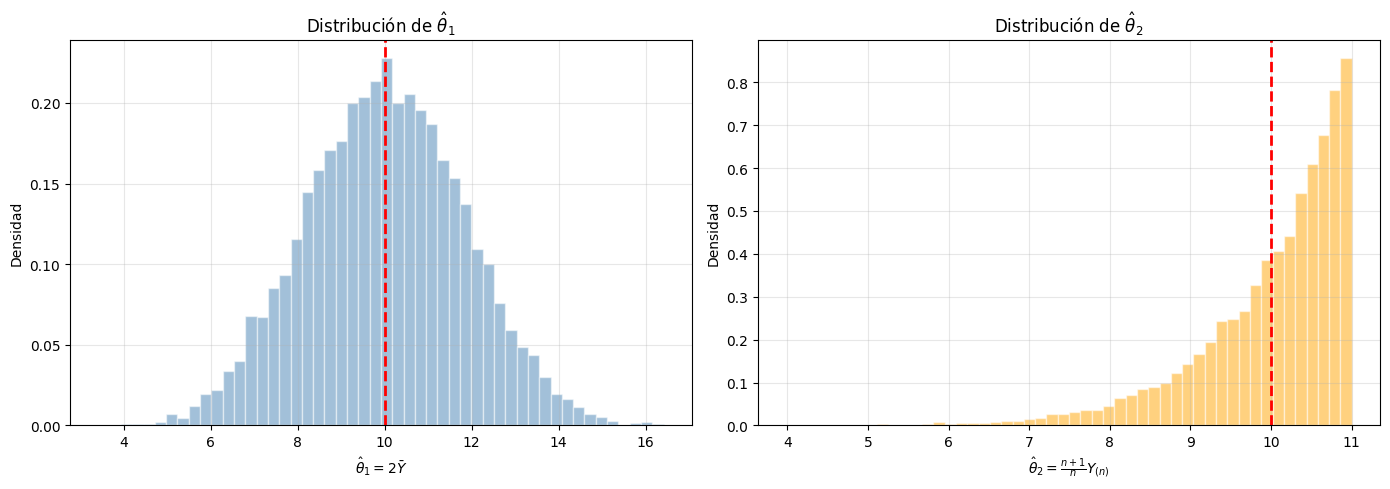

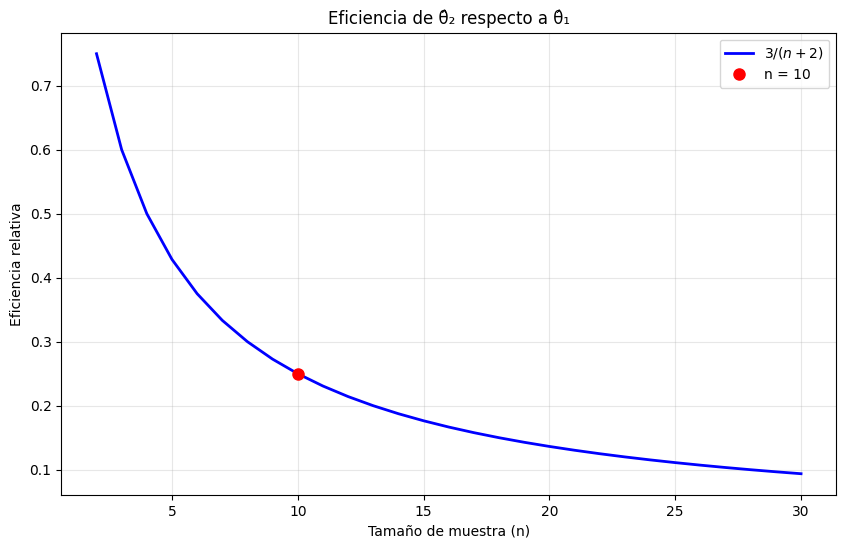

In [ ]:
# ============================================
# @title **C.  EJEMPLO 1: EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Parámetros
theta_verdadero = 10
n = 10
n_sim = 10000

# Simulación para comparar eficiencia
np.random.seed(123)

theta1_sim = []
theta2_sim = []

for _ in range(n_sim):
    muestra = np.random.uniform(0, theta_verdadero, n)
    theta1_sim.append(2 * np.mean(muestra))
    theta2_sim.append(((n + 1) / n) * np.max(muestra))

theta1_sim = np.array(theta1_sim)
theta2_sim = np.array(theta2_sim)

# Varianzas muestrales
var_theta1 = np.var(theta1_sim, ddof=1)
var_theta2 = np.var(theta2_sim, ddof=1)
eficiencia = var_theta2 / var_theta1
eficiencia_teorica = 3 / (n + 2)

print("=== EFICIENCIA RELATIVA - DISTRIBUCIÓN UNIFORME ===")
print(f"n = {n}, θ verdadero = {theta_verdadero}")
print(f"Varianza de θ̂₁ (2Ȳ): {var_theta1:.4f}")
print(f"Varianza de θ̂₂ ((n+1)/n * Y₍ₙ₎): {var_theta2:.4f}")
print(f"Eficiencia relativa (simulada): {eficiencia:.4f}")
print(f"Eficiencia relativa (teórica): {eficiencia_teorica:.4f}")

# ============================================
# VISUALIZACIÓN DE LAS DISTRIBUCIONES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de θ̂₁
axes[0].hist(theta1_sim, bins=50, density=True, alpha=0.5,
             color='steelblue', edgecolor='white')
axes[0].axvline(theta_verdadero, color='red', linestyle='--', lw=2)
axes[0].set_xlabel(r'$\hat{\theta}_1 = 2\bar{Y}$')
axes[0].set_ylabel('Densidad')
axes[0].set_title(r'Distribución de $\hat{\theta}_1$')
axes[0].grid(True, alpha=0.3)

# Histograma de θ̂₂
axes[1].hist(theta2_sim, bins=50, density=True, alpha=0.5,
             color='orange', edgecolor='white')
axes[1].axvline(theta_verdadero, color='red', linestyle='--', lw=2)
axes[1].set_xlabel(r'$\hat{\theta}_2 = \frac{n+1}{n} Y_{(n)}$')
axes[1].set_ylabel('Densidad')
axes[1].set_title(r'Distribución de $\hat{\theta}_2$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de eficiencia para diferentes n
n_values = np.arange(2, 31)
eficiencia_teorica_n = 3 / (n_values + 2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_values, eficiencia_teorica_n, 'b-', lw=2, label=r'$3/(n+2)$')
ax.plot(n, eficiencia_teorica, 'ro', markersize=8, label=f'n = {n}')
ax.set_xlabel('Tamaño de muestra (n)')
ax.set_ylabel('Eficiencia relativa')
ax.set_title('Eficiencia de θ̂₂ respecto a θ̂₁')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


[⬆️ Volver al inicio](#inicio2)

<a name="T22"></a>
## **22. DEMOSTRACIÓN DE CONSISTENCIA**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

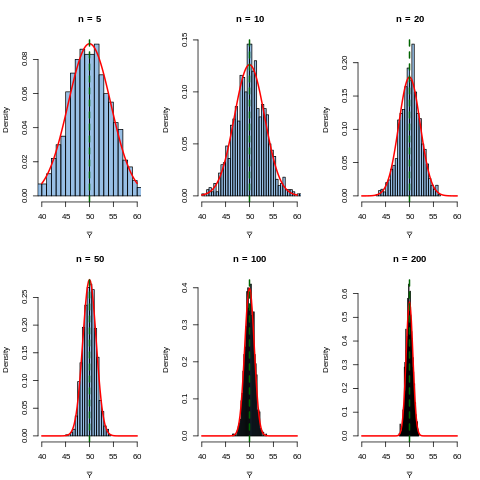

In [ ]:

# ============================================
# @title **B. DEMOSTRACIÓN DE CONSISTENCIA**
# ============================================
%%R
# Parámetros
mu_verdadera <- 50
sigma_verdadera <- 10
n_values <- c(5, 10, 20, 50, 100, 200, 500)
n_sim <- 1000

# Almacenar resultados
medias_por_n <- list()
varianzas_por_n <- list()

for (n in n_values) {
  medias <- replicate(n_sim, mean(rnorm(n, mu_verdadera, sigma_verdadera)))
  medias_por_n[[as.character(n)]] <- medias
  varianzas_por_n[[as.character(n)]] <- var(medias)
}

# Visualización
par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribuciones de la media para diferentes n
boxplot(medias_por_n, names = n_values,
        col = rgb(0.2, 0.5, 0.8, 0.5),
        main = "Distribución de la media muestral\npara diferentes tamaños de muestra",
        xlab = "Tamaño de muestra (n)", ylab = expression(bar(Y)))
abline(h = mu_verdadera, col = "red", lwd = 2, lty = 2)
legend("topright", legend = paste("μ =", mu_verdadera),
       col = "red", lty = 2, lwd = 2, bty = "n")

# Gráfico 2: Varianza de la media vs n
n_log <- log(n_values)
var_log <- log(unlist(varianzas_por_n))
plot(n_values, unlist(varianzas_por_n), type = "b", pch = 19,
     col = "steelblue", log = "xy",
     xlab = "Tamaño de muestra (n)", ylab = "Varianza de la media",
     main = "Varianza de la media vs tamaño de muestra\n(escala log-log)")
lines(n_values, sigma_verdadera^2 / n_values, col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Varianza simulada", "σ²/n"),
       col = c("steelblue", "red"), pch = c(19, NA), lty = c(1, 2), bty = "n")

# Gráfico 3: Histogramas para diferentes n
par(mfrow = c(2, 3))
for (n in n_values[1:6]) {
  medias <- medias_por_n[[as.character(n)]]
  hist(medias, breaks = 30, prob = TRUE,
       main = paste("n =", n),
       xlab = expression(bar(Y)),
       col = rgb(0.2, 0.5, 0.8, 0.5),
       xlim = c(40, 60))
  curve(dnorm(x, mu_verdadera, sigma_verdadera/sqrt(n)),
        add = TRUE, col = "red", lwd = 2)
  abline(v = mu_verdadera, col = "darkgreen", lwd = 2, lty = 2)
}




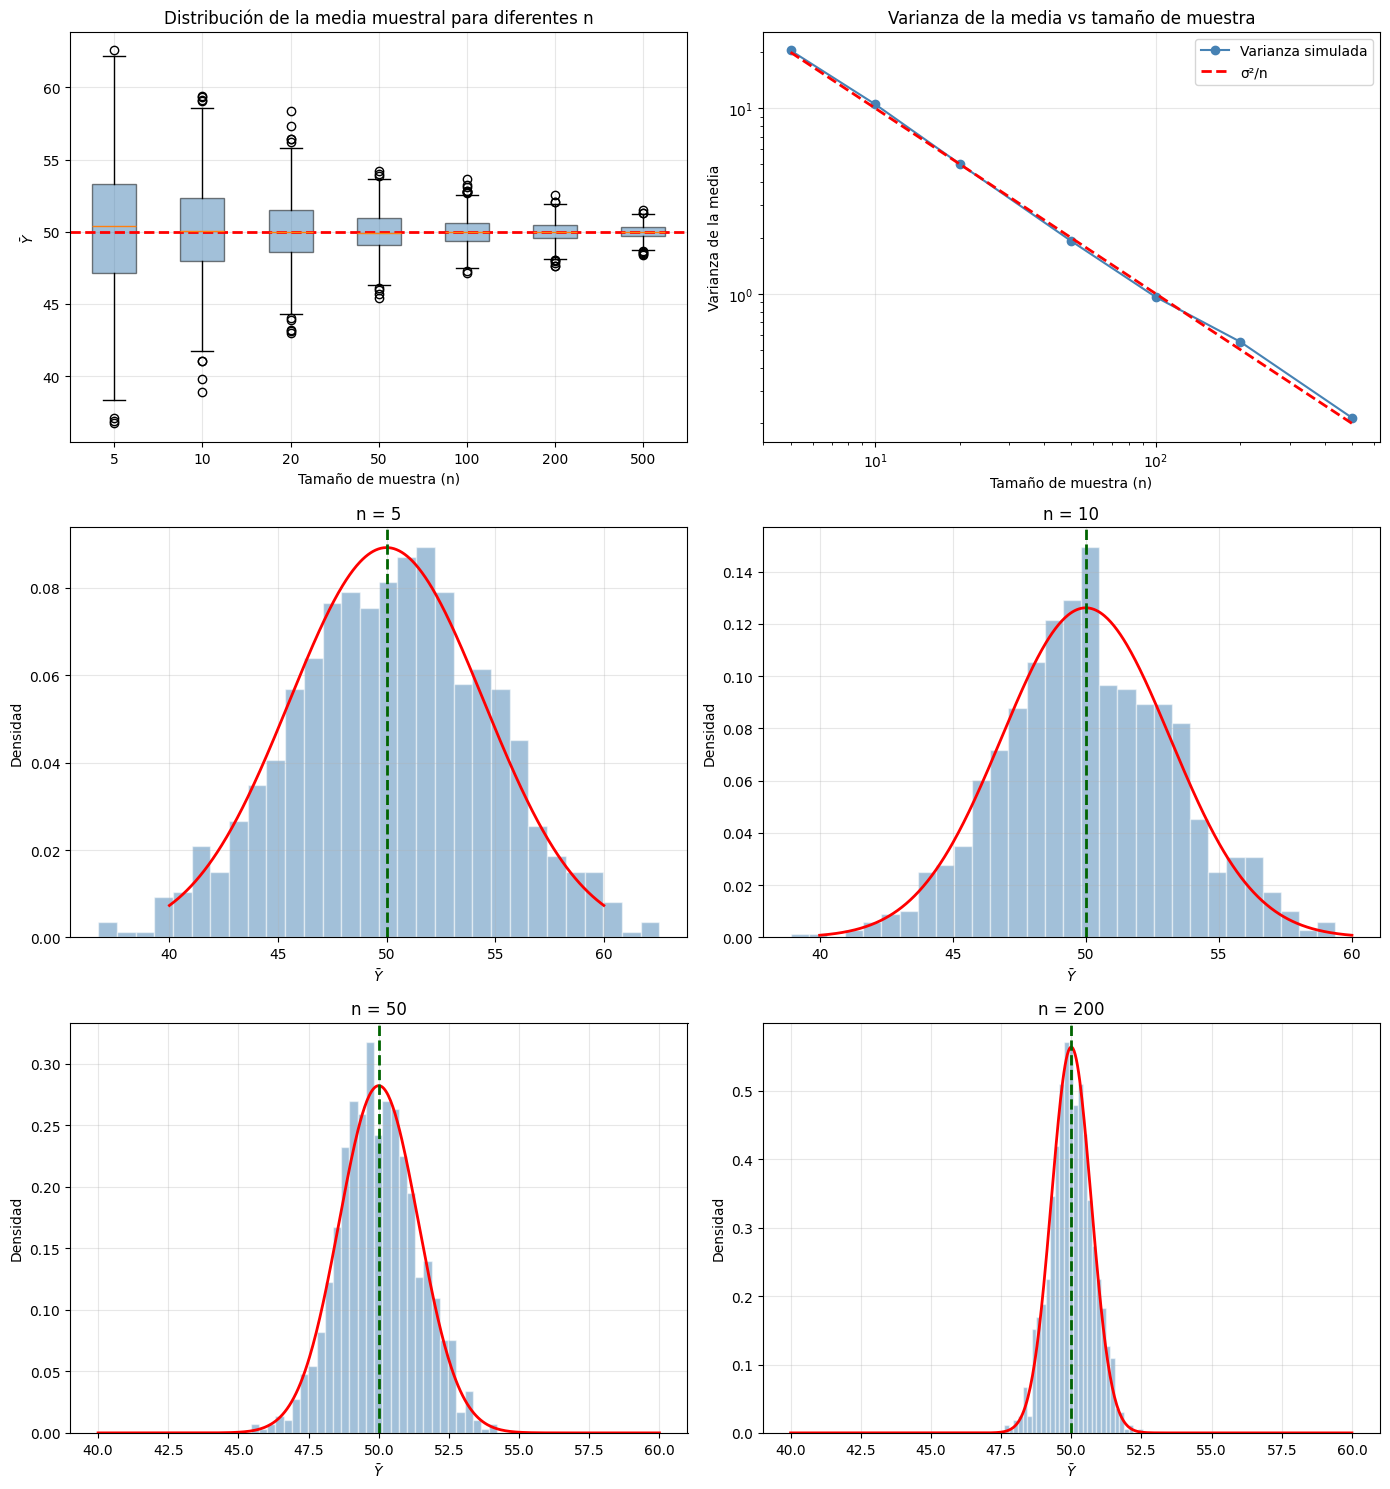

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
mu_verdadera = 50
sigma_verdadera = 10
n_values = [5, 10, 20, 50, 100, 200, 500]
n_sim = 1000

# Almacenar resultados
medias_por_n = {}
varianzas_por_n = {}

np.random.seed(123)

for n in n_values:
    medias = [np.mean(np.random.normal(mu_verdadera, sigma_verdadera, n))
              for _ in range(n_sim)]
    medias_por_n[n] = medias
    varianzas_por_n[n] = np.var(medias)

# Visualización
# Changed to 3 rows to accommodate all plots (2 main plots + 4 histograms)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Gráfico 1: Boxplots para diferentes n
data_to_plot = [medias_por_n[n] for n in n_values]
bp = axes[0, 0].boxplot(data_to_plot, labels=n_values, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.5)
axes[0, 0].axhline(mu_verdadera, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Tamaño de muestra (n)')
axes[0, 0].set_ylabel(r'$\bar{Y}$')
axes[0, 0].set_title('Distribución de la media muestral para diferentes n')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Varianza de la media vs n
n_list = list(varianzas_por_n.keys())
var_list = list(varianzas_por_n.values())
axes[0, 1].loglog(n_list, var_list, 'o-', color='steelblue', label='Varianza simulada')
axes[0, 1].loglog(n_list, [sigma_verdadera**2 / n for n in n_list],
                  'r--', lw=2, label='σ²/n')
axes[0, 1].set_xlabel('Tamaño de muestra (n)')
axes[0, 1].set_ylabel('Varianza de la media')
axes[0, 1].set_title('Varianza de la media vs tamaño de muestra')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráficos 3-6: Histogramas para diferentes n
n_subset = [5, 10, 50, 200]
for idx, n in enumerate(n_subset):
    # Corrected indexing for a 3x2 grid, placing histograms in the second and third rows
    ax = axes[1 + (idx // 2), idx % 2]

    medias = medias_por_n[n]
    ax.hist(medias, bins=30, density=True, alpha=0.5,
            color='steelblue', edgecolor='white')

    x_vals = np.linspace(40, 60, 500)
    y_vals = norm.pdf(x_vals, mu_verdadera, sigma_verdadera/np.sqrt(n))
    ax.plot(x_vals, y_vals, 'r-', lw=2)
    ax.axvline(mu_verdadera, color='darkgreen', linestyle='--', lw=2)
    ax.set_title(f'n = {n}')
    ax.set_xlabel(r'$\bar{Y}$')
    ax.set_ylabel('Densidad')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio2)

<a name="T23"></a>
## **23. COMPARACIÓN DE ESTIMADORES: MLE vs INSESGADO**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:

# ============================================
# COMPARACIÓN DE ESTIMADORES: MLE vs INSESGADO
# ============================================

# Simulación para comparar MLE y estimador insesgado de la varianza
set.seed(123)
n <- 30
mu_verdadera <- 100
sigma_verdadera <- 15
n_sim <- 5000

# Almacenar resultados
mle_mu <- numeric(n_sim)
mle_sigma2 <- numeric(n_sim)
insesgado_sigma2 <- numeric(n_sim)

for (i in 1:n_sim) {
  muestra <- rnorm(n, mu_verdadera, sigma_verdadera)
  mle_mu[i] <- mean(muestra)
  mle_sigma2[i] <- mean((muestra - mean(muestra))^2)
  insesgado_sigma2[i] <- var(muestra)
}

# Resultados
cat("=== COMPARACIÓN DE ESTIMADORES ===\n")
cat("n =", n, ", μ verdadera =", mu_verdadera, ", σ² verdadera =", sigma_verdadera^2, "\n\n")
cat("Estimador MLE de μ:\n")
cat("  Media:", round(mean(mle_mu), 2), "\n")
cat("  Sesgo:", round(mean(mle_mu) - mu_verdadera, 2), "\n")
cat("  Varianza:", round(var(mle_mu), 2), "\n\n")

cat("Estimador MLE de σ²:\n")
cat("  Media:", round(mean(mle_sigma2), 2), "\n")
cat("  Sesgo:", round(mean(mle_sigma2) - sigma_verdadera^2, 2), "\n")
cat("  Varianza:", round(var(mle_sigma2), 2), "\n\n")

cat("Estimador insesgado de σ²:\n")
cat("  Media:", round(mean(insesgado_sigma2), 2), "\n")
cat("  Sesgo:", round(mean(insesgado_sigma2) - sigma_verdadera^2, 2), "\n")
cat("  Varianza:", round(var(insesgado_sigma2), 2), "\n")

# Visualización
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Histogramas de los estimadores de σ²
hist(mle_sigma2, breaks = 40, prob = TRUE,
     col = rgb(0.8, 0.2, 0.2, 0.5), border = "white",
     main = "Estimadores de σ² (n=30)",
     xlab = "σ² estimada", xlim = c(100, 400))
hist(insesgado_sigma2, breaks = 40, prob = TRUE,
     col = rgb(0.2, 0.5, 0.8, 0.5), border = "white", add = TRUE)
abline(v = sigma_verdadera^2, col = "darkgreen", lwd = 2, lty = 2)
legend("topright",
       legend = c("MLE (sesgado)", "Insesgado", "σ² verdadera"),
       col = c(rgb(0.8, 0.2, 0.2, 0.5), rgb(0.2, 0.5, 0.8, 0.5), "darkgreen"),
       lty = c(NA, NA, 2), lwd = c(NA, NA, 2), pch = c(15, 15, NA), bty = "n")

# Boxplot comparativo
boxplot(mle_sigma2, insesgado_sigma2,
        names = c("MLE", "Insesgado"),
        col = c(rgb(0.8, 0.2, 0.2, 0.5), rgb(0.2, 0.5, 0.8, 0.5)),
        main = "Comparación de estimadores de σ²",
        ylab = "σ² estimada")
abline(h = sigma_verdadera^2, col = "darkgreen", lwd = 2, lty = 2)
legend("topright", legend = "σ² verdadera",
       col = "darkgreen", lty = 2, lwd = 2, bty = "n")






In [ ]:
# ============================================
# COMPARACIÓN DE ESTIMADORES: MLE vs INSESGADO
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Simulación para comparar MLE y estimador insesgado de la varianza
np.random.seed(123)
n = 30
mu_verdadera = 100
sigma_verdadera = 15
n_sim = 5000

# Almacenar resultados
mle_mu = []
mle_sigma2 = []
insesgado_sigma2 = []

for _ in range(n_sim):
    muestra = np.random.normal(mu_verdadera, sigma_verdadera, n)
    mle_mu.append(np.mean(muestra))
    mle_sigma2.append(np.var(muestra, ddof=0))  # MLE (divide por n)
    insesgado_sigma2.append(np.var(muestra, ddof=1))  # Insesgado (divide por n-1)

mle_mu = np.array(mle_mu)
mle_sigma2 = np.array(mle_sigma2)
insesgado_sigma2 = np.array(insesgado_sigma2)

# Resultados
print("=== COMPARACIÓN DE ESTIMADORES ===")
print(f"n = {n}, μ verdadera = {mu_verdadera}, σ² verdadera = {sigma_verdadera**2}\n")
print("Estimador MLE de μ:")
print(f"  Media: {np.mean(mle_mu):.2f}")
print(f"  Sesgo: {np.mean(mle_mu) - mu_verdadera:.2f}")
print(f"  Varianza: {np.var(mle_mu):.2f}\n")

print("Estimador MLE de σ²:")
print(f"  Media: {np.mean(mle_sigma2):.2f}")
print(f"  Sesgo: {np.mean(mle_sigma2) - sigma_verdadera**2:.2f}")
print(f"  Varianza: {np.var(mle_sigma2):.2f}\n")

print("Estimador insesgado de σ²:")
print(f"  Media: {np.mean(insesgado_sigma2):.2f}")
print(f"  Sesgo: {np.mean(insesgado_sigma2) - sigma_verdadera**2:.2f}")
print(f"  Varianza: {np.var(insesgado_sigma2):.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas de los estimadores de σ²
axes[0].hist(mle_sigma2, bins=40, density=True, alpha=0.5,
             color='red', edgecolor='white', label='MLE (sesgado)')
axes[0].hist(insesgado_sigma2, bins=40, density=True, alpha=0.5,
             color='steelblue', edgecolor='white', label='Insesgado')
axes[0].axvline(sigma_verdadera**2, color='darkgreen', linestyle='--', lw=2,
                label='σ² verdadera')
axes[0].set_xlabel('σ² estimada')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Estimadores de σ² (n=30)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot comparativo
data_to_plot = [mle_sigma2, insesgado_sigma2]
bp = axes[1].boxplot(data_to_plot, labels=['MLE', 'Insesgado'], patch_artist=True)
bp['boxes'][0].set_facecolor('red')
bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor('steelblue')
bp['boxes'][1].set_alpha(0.5)
axes[1].axhline(sigma_verdadera**2, color='darkgreen', linestyle='--', lw=2)
axes[1].set_ylabel('σ² estimada')
axes[1].set_title('Comparación de estimadores de σ²')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio3)